In [76]:
!pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn plotly scipy statsmodels imbalanced-learn ipykernel --quiet


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


This notebook implements **Aurora Finance's Banking Module**, covering three interconnected tasks:

---

## Task 1 — Loan Risk Assessment (2-Stage Pipeline)

**Stage 1: Predict Probability of Default (PD)**
- Loads `loan_portfolio.csv` and engineers features like `Loan_to_Income` ratio
- Runs **Ridge vs Lasso regression** using Leave-One-Out CV (ideal for small datasets) to predict each borrower's PD
- The lower-RMSE model wins and generates `PD_predicted` for every loan

**Stage 2: Risk Scoring & Classification**
- Builds a **weighted risk score** (1–3 scale) across 6 factors: DTI, Past Default, Interest Rate, Credit History, Loan-to-Income, and Predicted PD
- Cuts scores into `Low / Medium / High` risk classes
- Compares **Logistic Regression vs Decision Tree** (5-fold stratified CV, F1-macro) for classifying risk
- Maps risk classes to lending decisions: Low → APPROVE, Medium → MONITOR, High → REJECT

---

## Task 2 — Fraud Detection

Uses `transactions.csv` with two complementary models:

| Model | Type | Approach |
|---|---|---|
| Logistic Regression | Supervised | Trained on oversampled (SMOTE-like) data; threshold tuned via **F2-score** on PR curve (penalizes missed fraud more than false alarms) |
| Isolation Forest | Unsupervised | Anomaly detection using no labels; anomaly scores converted to pseudo-probabilities |

- **Ensemble alerting**: RED (both models flag) → highest confidence fraud; AMBER (either model flags) → review queue
- Outputs a flagged transactions CSV and a full visualization dashboard

---

## Task 3 — Integrated Lending Decision Engine

Combines outputs from Tasks 1 & 2:
- Re-runs the full pipeline end-to-end
- Joins fraud signals (aggregated per customer) to the loan portfolio
- Applies a **3-tier decision framework**:
  - `APPROVE` — Low risk, no fraud
  - `CONDITIONAL` — Medium risk; enhanced monitoring, collateral, rate premium (+1.5–2%)
  - `REJECT` — High risk, prior default, OR fraud detected (fraud overrides everything)
- Adds risk-based **interest rate adjustments** and specific **monitoring protocols**
- Outputs a final decision table CSV and a dashboard image

---

**Key design choices throughout:**
- LOOCV for small regression datasets (avoids overfitting on few samples)
- F2-score threshold optimization for fraud (recall weighted 2× over precision — missing fraud is costlier than false alarms)
- No data leakage: risk scores are excluded from classifier features

In [77]:
# =============================================================================
# Aurora Finance — Banking Module: Task 1
# Stage 1: Predict PD (Ridge vs Lasso)
# Stage 2: Risk Scoring + Classification (Logistic vs Decision Tree)
# =============================================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, StratifiedKFold, cross_val_score
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             classification_report)

# =============================================================================
# 0. DATA PREPARATION [cite: 133-157]
# =============================================================================

# Load dataset: loan_portfolio.csv [cite: 134]
df = pd.read_csv('sample_data/loan_portfolio.csv')

# Feature Engineering: Creating ratios as per ML Strategy
df['Loan_to_Income'] = df['Loan_Amount'] / df['Annual_Income']
df['Customer_Type_enc'] = (df['Customer_Type'] == 'Retail').astype(int)

print("=" * 60)
print("AURORA FINANCE — BANKING MODULE: TASK 1")
print("=" * 60)
print(f"Dataset shape: {df.shape}")
print()


AURORA FINANCE — BANKING MODULE: TASK 1
Dataset shape: (100, 12)



In [78]:
df

,Loan_ID,Customer_Type,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD,Loan_to_Income,Customer_Type_enc
0,1,Corporate,2676791,0.47,15,399593,13.39,36,0,0.22,0.149281,0
1,2,Retail,2740108,0.15,23,825131,12.80,36,0,0.02,0.301131,1
2,3,Corporate,4863177,0.20,15,83686,6.09,48,0,0.18,0.017208,0
3,4,Corporate,3383597,0.19,5,77661,5.05,48,0,0.07,0.022952,0
4,5,Retail,95953,0.62,21,578535,11.02,24,0,0.12,6.029358,1
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Retail,478345,0.54,15,965614,12.57,60,0,0.30,2.018656,1
96,97,Corporate,779074,0.55,15,550677,4.80,12,0,0.11,0.706835,0
97,98,Corporate,3715501,0.80,24,656465,5.75,60,0,0.23,0.176683,0
98,99,Corporate,1909490,0.42,22,313571,11.67,60,0,0.12,0.164217,0


In [79]:

# =============================================================================
# STAGE 1 — REGRESSION: PREDICT PD
# =============================================================================

print("-" * 60)
print("STAGE 1: PD PREDICTION (REGRESSION)")
print("-" * 60)

FEATURES_REG = ['Annual_Income', 'Debt_to_Income', 'Credit_History_Length',
                'Loan_Amount', 'Interest_Rate', 'Loan_Term_Months',
                'Past_Default', 'Loan_to_Income', 'Customer_Type_enc']

X_reg = df[FEATURES_REG].values
y_reg = df['PD'].values

# Standardize features for linear models
scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)

loo = LeaveOneOut()

def loocv_regression(model, X, y):
    """Run Leave-One-Out CV for precise evaluation on small samples."""
    y_pred_all = np.zeros(len(y))
    for train_idx, test_idx in loo.split(X):
        model.fit(X[train_idx], y[train_idx])
        y_pred_all[test_idx] = model.predict(X[test_idx])
    rmse = np.sqrt(mean_squared_error(y, y_pred_all))
    r2   = r2_score(y, y_pred_all)
    return rmse, r2

# --- Ridge Regression ---
ridge_alphas = [0.1, 1.0, 10.0, 100.0]
ridge_res = {a: loocv_regression(Ridge(alpha=a), X_reg_scaled, y_reg)[0] for a in ridge_alphas}
best_ridge_alpha = min(ridge_res, key=ridge_res.get)
ridge_rmse, ridge_r2 = loocv_regression(Ridge(alpha=best_ridge_alpha), X_reg_scaled, y_reg)

# --- Lasso Regression ---
lasso_alphas = [0.001, 0.01, 0.1]
lasso_res = {a: loocv_regression(Lasso(alpha=a), X_reg_scaled, y_reg)[0] for a in lasso_alphas}
best_lasso_alpha = min(lasso_res, key=lasso_res.get)
lasso_rmse, lasso_r2 = loocv_regression(Lasso(alpha=best_lasso_alpha), X_reg_scaled, y_reg)

# PRINTING BOTH RMSEs AS REQUESTED
print(f"Model Performance (LOOCV):")
print(f"  Ridge Regression RMSE: {ridge_rmse:.4f} (R²: {ridge_r2:.3f})")
print(f"  Lasso Regression RMSE: {lasso_rmse:.4f} (R²: {lasso_r2:.3f})")

# Determine Winner
if ridge_rmse <= lasso_rmse:
    stage1_winner = 'Ridge'
    best_stage1_model = Ridge(alpha=best_ridge_alpha)
    final_rmse = ridge_rmse
else:
    stage1_winner = 'Lasso'
    best_stage1_model = Lasso(alpha=best_lasso_alpha)
    final_rmse = lasso_rmse

print(f"Winner: {stage1_winner}")

# CRITICAL: Train on full data and generate PREDICTED PD for Stage 2
best_stage1_model.fit(X_reg_scaled, y_reg)
df['PD_predicted'] = best_stage1_model.predict(X_reg_scaled)
print(f"Stage 1 Complete. Predicted PD generated for risk scoring.")
print()


------------------------------------------------------------
STAGE 1: PD PREDICTION (REGRESSION)
------------------------------------------------------------
Model Performance (LOOCV):
  Ridge Regression RMSE: 0.0910 (R²: -0.054)
  Lasso Regression RMSE: 0.0895 (R²: -0.020)
Winner: Lasso
Stage 1 Complete. Predicted PD generated for risk scoring.



In [80]:
# =============================================================================
# STAGE 2 — RISK SCORING using CLASSIFICATION
# =============================================================================

print("-" * 60)
print("STAGE 2: RISK SCORING & CLASSIFICATION")
print("-" * 60)


# TODO: To make weights data-driven (for example from logistic regression coefficients or SHAP importance) 
# so they are learned from data instead of fixed manually.

# 2A. Weighted Scoring Logic (Incorporating Predicted PD) business rules based on domain knowledge and literature
WEIGHTS = {
    'Debt_to_Income': 0.20, 'Past_Default': 0.20, 'Interest_Rate': 0.15,
    'Credit_History_Length': 0.15, 'Loan_to_Income': 0.15, 'PD': 0.15
}

def score_1to3(val, thresholds, reverse=False):
    if not reverse:
        return 1 if val <= thresholds[0] else 2 if val <= thresholds[1] else 3
    return 1 if val >= thresholds[0] else 2 if val >= thresholds[1] else 3

df['s_DTI']     = df['Debt_to_Income'].apply(lambda x: score_1to3(x, [0.3, 0.6]))
df['s_CHL']     = df['Credit_History_Length'].apply(lambda x: score_1to3(x, [15, 7], reverse=True))
df['s_IR']      = df['Interest_Rate'].apply(lambda x: score_1to3(x, [7, 11]))
df['s_LTI']     = df['Loan_to_Income'].apply(lambda x: score_1to3(x, [0.15, 0.35]))
df['s_PastDef'] = df['Past_Default'].apply(lambda x: 3 if x == 1 else 1)
df['s_PD']      = df['PD_predicted'].apply(lambda x: score_1to3(x, [0.08, 0.20])) # USES PREDICTED PD

df['Risk_Score'] = (
    df['s_DTI'] * WEIGHTS['Debt_to_Income'] + df['s_PastDef'] * WEIGHTS['Past_Default'] +
    df['s_IR'] * WEIGHTS['Interest_Rate'] + df['s_CHL'] * WEIGHTS['Credit_History_Length'] +
    df['s_LTI'] * WEIGHTS['Loan_to_Income'] + df['s_PD'] * WEIGHTS['PD']
)

# Create Classification Labels
df['Risk_Class'] = pd.cut(df['Risk_Score'], bins=[0.9, 1.6, 2.2, 3.1], labels=['Low', 'Medium', 'High'])
df['Risk_Class_enc'] = df['Risk_Class'].map({'Low': 0, 'Medium': 1, 'High': 2})

# 2B. ML Classification (FIXED: No Data Leakage)
# We exclude 'Risk_Score' and 'Risk_Class' from features
FEATURES_CLF = ['Annual_Income', 'Debt_to_Income', 'Credit_History_Length',
                'Loan_Amount', 'Interest_Rate', 'Loan_Term_Months',
                'Past_Default', 'Loan_to_Income', 'Customer_Type_enc']

X_clf = df[FEATURES_CLF].values
y_clf = df['Risk_Class_enc'].values

X_clf_scaled = StandardScaler().fit_transform(X_clf)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Model Comparison
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
decisionTree = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)

log_f1 = cross_val_score(log_reg, X_clf_scaled, y_clf, cv=skf, scoring='f1_macro').mean()
dt_f1 = cross_val_score(decisionTree, X_clf_scaled, y_clf, cv=skf, scoring='f1_macro').mean()

print(f"Classification Performance (5-Fold CV F1-Macro):")
print(f"  Logistic Regression cross val score: {log_f1:.4f}")
print(f"  Decision Tree cross val score:       {dt_f1:.4f}")

# Select and Train Final Classifier
if log_f1 >= dt_f1:
    stage2_winner = 'Logistic Regression'
    best_clf = log_reg
else:
    stage2_winner = 'Decision Tree'
    best_clf = decisionTree

best_clf.fit(X_clf_scaled, y_clf)
df['Risk_Class_pred'] = best_clf.predict(X_clf_scaled)

print(f"\nFinal Selection: {stage2_winner}")
print(classification_report(y_clf, df['Risk_Class_pred'], target_names=['Low', 'Medium', 'High']))


------------------------------------------------------------
STAGE 2: RISK SCORING & CLASSIFICATION
------------------------------------------------------------
Classification Performance (5-Fold CV F1-Macro):
  Logistic Regression cross val score: 0.8017
  Decision Tree cross val score:       0.4793

Final Selection: Logistic Regression
              precision    recall  f1-score   support

         Low       0.77      0.96      0.86        25
      Medium       0.98      0.80      0.88        60
        High       0.75      1.00      0.86        15

    accuracy                           0.87       100
   macro avg       0.83      0.92      0.87       100
weighted avg       0.89      0.87      0.87       100



In [81]:
df

,Loan_ID,Customer_Type,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD,...,s_DTI,s_CHL,s_IR,s_LTI,s_PastDef,s_PD,Risk_Score,Risk_Class,Risk_Class_enc,Risk_Class_pred
0,1,Corporate,2676791,0.47,15,399593,13.39,36,0,0.22,...,2,1,3,1,1,2,1.65,Medium,1,1
1,2,Retail,2740108,0.15,23,825131,12.80,36,0,0.02,...,1,1,3,2,1,2,1.60,Low,0,0
2,3,Corporate,4863177,0.20,15,83686,6.09,48,0,0.18,...,1,1,1,1,1,2,1.15,Low,0,0
3,4,Corporate,3383597,0.19,5,77661,5.05,48,0,0.07,...,1,3,1,1,1,2,1.45,Low,0,0
4,5,Retail,95953,0.62,21,578535,11.02,24,0,0.12,...,3,1,3,3,1,2,2.15,Medium,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Retail,478345,0.54,15,965614,12.57,60,0,0.30,...,2,1,3,3,1,2,1.95,Medium,1,1
96,97,Corporate,779074,0.55,15,550677,4.80,12,0,0.11,...,2,1,1,3,1,2,1.65,Medium,1,1
97,98,Corporate,3715501,0.80,24,656465,5.75,60,0,0.23,...,3,1,1,2,1,2,1.70,Medium,1,0
98,99,Corporate,1909490,0.42,22,313571,11.67,60,0,0.12,...,2,1,3,2,1,2,1.80,Medium,1,0


In [82]:
# =============================================================================
# EXECUTIVE SUMMARY OF LENDING DECISIONS
# =============================================================================
decision_map = {0: 'APPROVE', 1: 'MONITOR', 2: 'REJECT'}
print("-" * 60)
print("EXECUTIVE LENDING DECISIONS")
print("-" * 60)
for i, label in enumerate(['Low', 'Medium', 'High']):
    count = (df['Risk_Class_pred'] == i).sum()
    print(f"  {label:6s} Risk -> {decision_map[i]:8s} : {count:2d} loans")

------------------------------------------------------------
EXECUTIVE LENDING DECISIONS
------------------------------------------------------------
  Low    Risk -> APPROVE  : 31 loans
  Medium Risk -> MONITOR  : 49 loans
  High   Risk -> REJECT   : 20 loans


Compacted conversationLooking at the classification_report output, I'll break down each metric and what it means for your loan risk classification model:

## **The Four Columns Explained:**

### **1. Support** (rightmost column)
The number of actual samples in each class:
- **Low**: 25 loans were actually classified as "Low" risk (by the weighted scoring rule)
- **Medium**: 60 loans were actually classified as "Medium" risk
- **High**: 15 loans were actually classified as "High" risk
- **Total**: 100 loans tested

---

### **2. Precision** (left column)
**Definition**: Of all loans the model *predicted* as a risk class, what % were actually correct?

$$\text{Precision} = \frac{\text{True Positives}}{\text{True Positives + False Positives}}$$

**Row interpretation:**
- **Low (0.77)**: 77% of loans predicted as "Low" risk were actually low risk. 23% were false alarms (model said low, but they were actually medium/high).
- **Medium (0.98)**: 98% of loans predicted as "Medium" were correct. Very few false positives!
- **High (0.75)**: 75% of loans predicted as "High" were actually high. 25% were false alarms.

**Business impact**: High precision means fewer wrongly-rejected loans. Low precision means wasting time reviewing safe loans.

---

### **3. Recall** (middle-left column)
**Definition**: Of all loans that *actually belong* to a risk class, what % did the model catch?

$$\text{Recall} = \frac{\text{True Positives}}{\text{True Positives + False Negatives}}$$

**Row interpretation:**
- **Low (0.96)**: The model caught 96% of actual low-risk loans. Only missed 4% (dangerous—those risky loans were mislabeled as medium/high).
- **Medium (0.80)**: The model caught 80% of actual medium-risk loans. Missed 20% (some medium loans were marked as low or high).
- **High (1.00)**: Perfect! Caught all 15 actual high-risk loans—zero missed fraud/risk cases.

**Business impact**: High recall is critical for risk management. Missing a risky loan (low recall) is costlier than flagging a safe loan (low precision).

---

### **4. F1-Score** (middle-right column)
**Definition**: The harmonic mean of Precision and Recall—balances both metrics.

$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision + Recall}}$$

**Row interpretation:**
- **Low (0.86)**: Balanced score. High recall (0.96) compensates for lower precision (0.77).
- **Medium (0.88)**: Excellent F1—both precision (0.98) and recall (0.80) are strong.
- **High (0.86)**: Strong F1—perfect recall (1.00) makes up for moderate precision (0.75).

**Business impact**: F1 says "how well does this class balance catching real cases vs. avoiding false alarms?"

---

## **Summary Rows:**

| Metric | Value | Meaning |
|--------|-------|---------|
| **accuracy** | 0.87 | 87% of all predictions were correct (not class-specific) |
| **macro avg** | P=0.83, R=0.92, F1=0.87 | Average across all three classes (treats each class equally) |
| **weighted avg** | P=0.89, R=0.87, F1=0.87 | Average weighted by class size (Medium class dominates) |

---

## **Model Performance Assessment:**

✅ **Strengths:**
- **High Recall (0.92 macro)**: Excellent at catching risky loans (especially High risk: 100% recall)
- **Balanced F1-score (0.87)**: Good trade-off between precision and recall
- **Overall accuracy (87%)**: Strong predictive power

⚠️ **Concerns:**
- **Medium class precision (0.98) but recall (0.80)**: Missing 20% of medium-risk loans—some slip through as "low"
- **Low class precision (0.77)**: Some truly risky loans classified as safe

---

## **For Your Lending Context:**

| Risk Class | Best Metric | Why | Action |
|-----------|-------------|-----|--------|
| **Low** | ← Recall (0.96) | Missing a risky loan is worse than flagging a safe one | Safe; trust the model |
| **Medium** | ← Recall (0.80) | 20% escape to "Low"—add manual review? | Consider monitoring |
| **High** | ← Recall (1.00) ✅ | Perfect catch rate—zero missed high-risk cases | REJECT with confidence |

**Bottom line**: Your Logistic Regression classifier performs well, especially at identifying truly high-risk loans (100% recall). The main gap is missing some medium-risk loans that slip into the "low" category, but overall precision (0.89 weighted) is solid.

### Step2 Task 2 Fraud detection

In [83]:
# =============================================================================
# Aurora Finance — Fraud Detection
# Models: Logistic Regression (Supervised) + Isolation Forest (Unsupervised)
# Threshold Selection: Precision-Recall Curve (Method 2 / F2-Score)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    precision_recall_curve, f1_score, fbeta_score,
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
    precision_score, recall_score
)
from sklearn.pipeline import Pipeline
# Manual minority oversampling (SMOTE-like, no external lib needed)

# ── Colour palette ────────────────────────────────────────────────────────────
C_LR   = "#2E86AB"   # blue  — Logistic Regression
C_IF   = "#E84855"   # red   — Isolation Forest
C_GOLD = "#F6AE2D"   # gold  — highlights
C_DARK = "#1A1A2E"   # near-black
C_LIGHT= "#F4F6F9"   # off-white background
C_GRID = "#D5D8DC"

plt.rcParams.update({
    "figure.facecolor": C_LIGHT,
    "axes.facecolor":   C_LIGHT,
    "axes.edgecolor":   C_GRID,
    "axes.grid":        True,
    "grid.color":       C_GRID,
    "grid.linewidth":   0.6,
    "font.family":      "DejaVu Sans",
    "font.size":        10,
    "axes.titlesize":   11,
    "axes.titleweight": "bold",
    "axes.labelsize":   9,
})

# =============================================================================
# 1.  LOAD & EXPLORE
# =============================================================================
df = pd.read_csv("sample_data/transactions.csv")

print("=" * 60)
print("AURORA FINANCE — FRAUD DETECTION PIPELINE")
print("=" * 60)
print(f"\nDataset shape : {df.shape}")
print(f"Fraud cases   : {df['Fraud_Flag'].sum()}  ({df['Fraud_Flag'].mean()*100:.1f}%)")
print(f"Legit cases   : {(df['Fraud_Flag']==0).sum()}")

df


AURORA FINANCE — FRAUD DETECTION PIPELINE

Dataset shape : (200, 6)
Fraud cases   : 9  (4.5%)
Legit cases   : 191


,Transaction_ID,Customer_ID,Amount,Transaction_Type,Timestamp,Fraud_Flag
0,1,57,35200,Withdrawal,2025-09-03 10:47:51.200706,0
1,2,16,25871,Transfer,2025-12-31 10:47:51.200738,0
2,3,56,26710,Withdrawal,2025-09-12 10:47:51.200752,0
3,4,10,5134,Withdrawal,2025-03-29 10:47:51.200763,0
4,5,30,16711,Transfer,2025-06-08 10:47:51.200773,0
...,...,...,...,...,...,...
195,196,96,8651,Withdrawal,2025-05-30 10:47:51.202565,0
196,197,98,33712,Transfer,2025-04-21 10:47:51.202574,0
197,198,63,33332,Withdrawal,2025-07-22 10:47:51.202583,0
198,199,28,21338,Withdrawal,2025-03-30 10:47:51.202591,1


In [84]:
# =============================================================================
# 2.  FEATURE ENGINEERING
# =============================================================================
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

# Time-based features
df["Hour"]       = df["Timestamp"].dt.hour
df["DayOfWeek"]  = df["Timestamp"].dt.dayofweek   # 0=Mon, 6=Sun
df["IsWeekend"]  = (df["DayOfWeek"] >= 5).astype(int)
df["IsNightTxn"] = ((df["Hour"] < 6) | (df["Hour"] >= 22)).astype(int)

# Amount-based features (per-customer normalisation)
cust_stats = df.groupby("Customer_ID")["Amount"].agg(["mean", "std"]).rename(
    columns={"mean": "Cust_Amt_Mean", "std": "Cust_Amt_Std"}
)
df = df.join(cust_stats, on="Customer_ID")
df["Cust_Amt_Std"]   = df["Cust_Amt_Std"].fillna(1)          # single-txn customers
df["Amount_ZScore"]  = (df["Amount"] - df["Cust_Amt_Mean"]) / df["Cust_Amt_Std"]
df["Amount_Log"]     = np.log1p(df["Amount"])

# Transaction velocity — count per customer in rolling 24-hr window
# INFO: Implement actual rolling count instead of cumulative count for more accuracy, but this is a simplified version due to time constraints.
df = df.sort_values(["Customer_ID", "Timestamp"])
df["Velocity_24h"] = (
    df.groupby("Customer_ID")["Timestamp"]
      .transform(lambda s: s.expanding().count())
)

# Transaction type encoding
le = LabelEncoder()
df["TxnType_Enc"] = le.fit_transform(df["Transaction_Type"])

print("\nEngineered features added:")
new_cols = ["Hour","DayOfWeek","IsWeekend","IsNightTxn",
            "Amount_ZScore","Amount_Log","Velocity_24h","TxnType_Enc","Cust_Amt_Std","Timestamp"]
df.round(2)



Engineered features added:


,Transaction_ID,Customer_ID,Amount,Transaction_Type,Timestamp,Fraud_Flag,Hour,DayOfWeek,IsWeekend,IsNightTxn,Cust_Amt_Mean,Cust_Amt_Std,Amount_ZScore,Amount_Log,Velocity_24h,TxnType_Enc
75,173,2,38900,Withdrawal,2025-06-14 10:47:51.202312,0,10,5,1,0,38900.00,1.00,0.00,10.57,1.0,2
38,78,3,48340,Withdrawal,2025-04-01 10:47:51.201434,0,10,1,0,0,35904.00,18285.25,0.68,10.79,1.0,2
61,60,3,44463,Transfer,2025-05-04 10:47:51.201267,0,10,6,1,0,35904.00,18285.25,0.47,10.70,2.0,1
112,12,3,14909,Transfer,2025-09-01 10:47:51.200839,0,10,0,0,0,35904.00,18285.25,-1.15,9.61,3.0,1
81,48,4,16472,Payment,2025-06-27 10:47:51.201160,0,10,4,0,0,16472.00,1.00,0.00,9.71,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,86,98,23069,Withdrawal,2026-01-05 10:47:51.201531,0,10,0,0,0,18203.25,9306.58,0.52,10.05,8.0,2
31,69,99,34500,Transfer,2025-03-28 10:47:51.201347,0,10,4,0,0,26995.00,10613.67,0.71,10.45,1.0,1
57,80,99,19490,Payment,2025-04-30 10:47:51.201452,0,10,2,0,0,26995.00,10613.67,-0.71,9.88,2.0,0
141,172,100,6140,Transfer,2025-10-10 10:47:51.202303,0,10,4,0,0,14310.50,11554.83,-0.71,8.72,1.0,1


In [85]:
cust_stats.round(2)

,Cust_Amt_Mean,Cust_Amt_Std
Customer_ID,,
2,38900.00,NaN
3,35904.00,18285.25
4,16472.00,NaN
5,27086.33,11903.90
6,40466.00,10514.68
...,...,...
96,20210.33,10031.69
97,38609.00,NaN
98,18203.25,9306.58


In [86]:
df[new_cols].describe().round(2)

,Hour,DayOfWeek,IsWeekend,IsNightTxn,Amount_ZScore,Amount_Log,Velocity_24h,TxnType_Enc,Cust_Amt_Std,Timestamp
count,200.0,200.00,200.00,200.0,200.00,200.00,200.00,200.00,200.00,200
mean,10.0,2.96,0.27,0.0,0.00,9.89,2.08,1.01,11463.45,2025-07-27 19:11:51.201650
min,10.0,0.00,0.00,0.0,-1.43,5.05,1.00,0.00,1.00,2025-01-26 10:47:51.201107
25%,10.0,1.00,0.00,0.0,-0.71,9.51,1.00,0.00,6192.01,2025-04-18 04:47:51.201208
50%,10.0,3.00,0.00,0.0,0.00,10.16,2.00,1.00,11646.10,2025-08-19 22:47:51.201696
75%,10.0,5.00,1.00,0.0,0.71,10.50,3.00,2.00,16484.78,2025-10-26 04:47:51.201142
max,10.0,6.00,1.00,0.0,1.75,10.82,8.00,2.00,27392.61,2026-01-25 10:47:51.200829
std,0.0,1.97,0.45,0.0,0.76,0.88,1.31,0.83,7307.00,NaN


## Groupby amount and customerId 
block computes **per-customer spending statistics** to normalize transaction amounts, so the model can detect anomalies relative to *each customer's own behavior* rather than the global average.

---

### Step-by-Step Breakdown

### Step 1: Compute per-customer mean and std
```python
cust_stats = df.groupby("Customer_ID")["Amount"].agg(["mean", "std"])
```
Groups all transactions by customer, then calculates their typical spending pattern.

**Example data:**

| Customer_ID | Transaction | Amount |
|-------------|-------------|--------|
| C001 | T1 | $100 |
| C001 | T2 | $120 |
| C001 | T3 | $110 |
| C002 | T4 | $5,000 |
| C002 | T5 | $4,800 |

**After groupby:**

| Customer_ID | Cust_Amt_Mean | Cust_Amt_Std |
|-------------|---------------|--------------|
| C001 | $110 | $10 |
| C002 | $4,900 | $141 |

---

### Step 2: Join stats back to every transaction row
```python
df = df.join(cust_stats, on="Customer_ID")
df["Cust_Amt_Std"] = df["Cust_Amt_Std"].fillna(1)  # if customer has only 1 transaction
```
Each transaction row now knows its customer's mean and std. The `fillna(1)` avoids division-by-zero for single-transaction customers.

---

### Step 3: Z-Score — how unusual is THIS transaction for THIS customer?
```python
df["Amount_ZScore"] = (df["Amount"] - df["Cust_Amt_Mean"]) / df["Cust_Amt_Std"]
```

$$\text{Z-Score} = \frac{\text{Transaction Amount} - \text{Customer Mean}}{\text{Customer Std Dev}}$$

**Example:**

| Transaction | Amount | Cust Mean | Cust Std | Z-Score | Interpretation |
|-------------|--------|-----------|----------|---------|----------------|
| C001 - T1 | $100 | $110 | $10 | **-1.0** | Slightly below normal |
| C001 - fraud | $500 | $110 | $10 | **+39.0** | ⚠️ Extreme anomaly! |
| C002 - T4 | $5,000 | $4,900 | $141 | **+0.7** | Completely normal for C002 |

**Key insight**: A $500 transaction is NOT suspicious for C002 (a high spender), but IS extremely suspicious for C001 (a low spender). Z-Score captures this automatically.

---

### Step 4: Log-transform of amount
```python
df["Amount_Log"] = np.log1p(df["Amount"])
```
- `log1p(x) = log(1 + x)` — handles zero amounts safely
- Compresses the large scale of amounts (e.g., $50,000 → 10.8, $50 → 3.9)
- Makes the distribution less skewed, which helps Logistic Regression converge better

---

### Why Both Features?

| Feature | What it captures |
|---------|-----------------|
| `Amount_Log` | Absolute transaction size (large amounts are generally riskier) |
| `Amount_ZScore` | Relative unusualness for that specific customer (behavioral anomaly) |

Together they give the model two lenses: *how big* the transaction is, and *how weird* it is for that customer.

## The column **velocity_24** 
computes **transaction velocity** — how many transactions a customer has made up to and including each transaction, in chronological order.

---

### Step-by-Step Breakdown

### Step 1: Sort by customer and time
```python
df = df.sort_values(["Customer_ID", "Timestamp"])
```
Reorders the dataframe so each customer's transactions appear in chronological order. This is critical — velocity is meaningless if transactions are out of order.

---

### Step 2: Expanding count per customer
```python
df["Velocity_24h"] = (
    df.groupby("Customer_ID")["Timestamp"]
      .transform(lambda s: s.expanding().count())
)
```

Breaking this down piece by piece:

| Part | What it does |
|------|-------------|
| `groupby("Customer_ID")` | Process each customer independently |
| `["Timestamp"]` | Look at the Timestamp column |
| `.expanding()` | Create a growing window: row 1, then rows 1-2, then rows 1-2-3... |
| `.count()` | Count how many rows are in each window |
| `.transform(...)` | Write the result back into the original df, row by row |

---

### Concrete Example

**Raw sorted data for C001:**

| Row | Customer_ID | Timestamp | Amount |
|-----|-------------|-----------|--------|
| 1 | C001 | 09:00 | $100 |
| 2 | C001 | 11:30 | $200 |
| 3 | C001 | 14:00 | $50 ← fraud |
| 4 | C002 | 10:00 | $500 |

**After `expanding().count()`:**

| Row | Customer_ID | Timestamp | Velocity_24h | Meaning |
|-----|-------------|-----------|--------------|---------|
| 1 | C001 | 09:00 | **1** | 1st transaction of the day |
| 2 | C001 | 11:30 | **2** | 2nd transaction so far |
| 3 | C001 | 14:00 | **3** | 3rd transaction so far |
| 4 | C002 | 10:00 | **1** | C002's 1st transaction |

---

### Why is this a fraud signal?

Fraudsters often **burst-transact** — making many transactions in a short window before the card is blocked. A customer suddenly hitting transaction 8, 9, 10 in rapid succession is anomalous compared to their normal 1-2/day pattern.

| Velocity_24h | Risk Interpretation |
|-------------|---------------------|
| 1–2 | Normal behavior |
| 5–8 | Elevated — worth watching |
| 10+ | Strong anomaly signal |

---

### Important Caveat
The name `Velocity_24h` is slightly misleading — the code uses `expanding().count()` which counts **all transactions ever seen** for that customer up to that point (cumulative), not strictly within the last 24 hours. A true 24-hour rolling window would require `rolling('24h')` on a time-indexed series. This is a simplification that still captures *relative* activity surge as a proxy for velocity.

In [87]:
from imblearn.over_sampling import SMOTE

# =============================================================================
# 3.  PREPARE MATRICES
# =============================================================================
FEATURES = ["Amount_Log", "Amount_ZScore", "Hour", "IsWeekend",
            "IsNightTxn", "Velocity_24h", "TxnType_Enc"]

X = df[FEATURES].values
y = df["Fraud_Flag"].values

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42, k_neighbors=3)
X_sm, y_sm = smote.fit_resample(X_scaled, y)
print(f"\nAfter oversampling — Fraud: {y_sm.sum()}  Legit: {(y_sm==0).sum()}\n")


After oversampling — Fraud: 191  Legit: 191



In [88]:
# Manual oversampling of minority class (replicates with small noise)
rng = np.random.RandomState(42)
fraud_idx = np.where(y == 1)[0]
n_needed  = (y == 0).sum() - (y == 1).sum()
oversample_idx = rng.choice(fraud_idx, size=n_needed, replace=True)
noise = rng.normal(0, 0.05, (n_needed, X_scaled.shape[1]))
X_sm = np.vstack([X_scaled, X_scaled[oversample_idx] + noise])
y_sm = np.concatenate([y, np.ones(n_needed, dtype=int)])
print(f"\nAfter oversampling — Fraud: {y_sm.sum()}  Legit: {(y_sm==0).sum()}\n")


After oversampling — Fraud: 191  Legit: 191



F2-score is an F-measure that gives recall more importance than precision.

Definition:
$$
F_\beta = (1+\beta^2)\frac{PR}{\beta^2P + R}
$$

For F2, $\beta=2$:
$$
F_2 = 5\frac{PR}{4P + R}
$$

Here:
- $P$ = precision = among flagged frauds, how many are truly fraud
- $R$ = recall = among true frauds, how many you caught

Why F2 over F1:
- F1 balances precision and recall equally
- F2 weights recall about 2x more than precision
- In fraud, missing a fraud (false negative) is usually costlier than a false alarm (false positive), so recall should dominate

Quick intuition:
- If model A has higher recall but slightly lower precision, F2 may still prefer A
- F1 might prefer a more “balanced” model and could under-reward recall-heavy behavior

Small example:
- Model A: $P=0.50,\ R=0.90$
- Model B: $P=0.70,\ R=0.60$

F1:
- A: $\frac{2(0.5)(0.9)}{0.5+0.9}=0.64$
- B: $\frac{2(0.7)(0.6)}{0.7+0.6}=0.65$  (B slightly better)

F2:
- A: $5\frac{0.5\cdot0.9}{4(0.5)+0.9}=0.78$
- B: $5\frac{0.7\cdot0.6}{4(0.7)+0.6}=0.62$  (A clearly better)

So F2 picks the model that catches more fraud, even with more false alarms, which matches your business objective in this fraud stage.

In [89]:
# =============================================================================
# 4.  MODEL A — LOGISTIC REGRESSION  (Supervised)
# =============================================================================
print("\n" + "─"*60)
print("MODEL A: LOGISTIC REGRESSION")
print("─"*60)

lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, C=0.5)
lr.fit(X_sm, y_sm)

# Out-of-fold probabilities on ORIGINAL (imbalanced) data for honest evaluation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_base = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, C=0.5)
lr_probs_oof = cross_val_predict(lr_base, X_scaled, y, cv=cv, method="predict_proba")[:, 1]

# ── Precision-Recall curve & F2-optimal threshold ────────────────────────────
lr_precision, lr_recall, lr_thresholds = precision_recall_curve(y, lr_probs_oof)

f2_scores = []
for p, r in zip(lr_precision[:-1], lr_recall[:-1]):
    denom = (4*p + r)
    f2_scores.append((5*p*r / denom) if denom > 0 else 0)

best_idx_lr   = int(np.argmax(f2_scores))
best_thresh_lr = lr_thresholds[best_idx_lr]
best_f2_lr     = f2_scores[best_idx_lr]

print(f"  Optimal threshold (F2): {best_thresh_lr:.3f}")
print(f"  Best F2-score         : {best_f2_lr:.3f}")

lr_preds = (lr_probs_oof >= best_thresh_lr).astype(int)

print("\nClassification Report (LR):")
print(classification_report(y, lr_preds, target_names=["Legit","Fraud"], digits=3))

lr_metrics = {
    "Precision": precision_score(y, lr_preds, zero_division=0),
    "Recall":    recall_score(y, lr_preds),
    "F2-Score":  fbeta_score(y, lr_preds, beta=2),
    "AUC-ROC":   roc_auc_score(y, lr_probs_oof),
    "PR-AUC":    average_precision_score(y, lr_probs_oof),
}
print("Summary metrics (LR):", {k: f"{v:.3f}" for k, v in lr_metrics.items()})




────────────────────────────────────────────────────────────
MODEL A: LOGISTIC REGRESSION
────────────────────────────────────────────────────────────
  Optimal threshold (F2): 0.169
  Best F2-score         : 0.197

Classification Report (LR):
              precision    recall  f1-score   support

       Legit      1.000     0.042     0.080       191
       Fraud      0.047     1.000     0.090         9

    accuracy                          0.085       200
   macro avg      0.523     0.521     0.085       200
weighted avg      0.957     0.085     0.081       200

Summary metrics (LR): {'Precision': '0.047', 'Recall': '1.000', 'F2-Score': '0.197', 'AUC-ROC': '0.231', 'PR-AUC': '0.031'}


In [90]:
# =============================================================================
# 5.  MODEL B — ISOLATION FOREST  (Unsupervised)
# =============================================================================
print("\n" + "─"*60)
print("MODEL B: ISOLATION FOREST")
print("─"*60)

contamination = round(y.mean(), 3)        # use actual fraud rate
iso = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=42,
    max_samples="auto"
)
iso.fit(X_scaled)                         # trained on ALL data — no labels used

# Raw anomaly scores (more negative = more anomalous)
iso_scores_raw = iso.decision_function(X_scaled)   # higher = more normal
iso_anomaly    = -iso_scores_raw                   # flip so higher = more fraud-like

# Convert to pseudo-probabilities via min-max scaling for PR curve
iso_probs = (iso_anomaly - iso_anomaly.min()) / (iso_anomaly.max() - iso_anomaly.min())

iso_precision, iso_recall, iso_thresholds = precision_recall_curve(y, iso_probs)

f2_scores_iso = []
# last but one is dropped because it corresponds to threshold beyond max prob, which is not meaningful for classification. This is a quirk of how precision_recall_curve outputs thresholds.
for p, r in zip(iso_precision[:-1], iso_recall[:-1]):
    denom = (4*p + r)
    f2_scores_iso.append((5*p*r / denom) if denom > 0 else 0)

best_idx_iso    = int(np.argmax(f2_scores_iso))
best_thresh_iso = iso_thresholds[best_idx_iso]
best_f2_iso     = f2_scores_iso[best_idx_iso]

print(f"  Contamination param   : {contamination}")
print(f"  Optimal threshold (F2): {best_thresh_iso:.3f}")
print(f"  Best F2-score         : {best_f2_iso:.3f}")
# iso_thresholds is the array of cutoff values returned by precision_recall_curve(). 
# Each threshold is a score value — if your model's output score ≥ threshold, you predict fraud.
iso_preds = (iso_probs >= best_thresh_iso).astype(int)

print("\nClassification Report (IF):")
print(classification_report(y, iso_preds, target_names=["Legit","Fraud"], digits=3))

iso_metrics = {
    "Precision": precision_score(y, iso_preds, zero_division=0),
    "Recall":    recall_score(y, iso_preds),
    "F2-Score":  fbeta_score(y, iso_preds, beta=2),
    "AUC-ROC":   roc_auc_score(y, iso_probs),
    "PR-AUC":    average_precision_score(y, iso_probs),
}
print("Summary metrics (IF):", {k: f"{v:.3f}" for k, v in iso_metrics.items()})



────────────────────────────────────────────────────────────
MODEL B: ISOLATION FOREST
────────────────────────────────────────────────────────────
  Contamination param   : 0.045
  Optimal threshold (F2): 0.328
  Best F2-score         : 0.223

Classification Report (IF):
              precision    recall  f1-score   support

       Legit      0.968     0.628     0.762       191
       Fraud      0.066     0.556     0.118         9

    accuracy                          0.625       200
   macro avg      0.517     0.592     0.440       200
weighted avg      0.927     0.625     0.733       200

Summary metrics (IF): {'Precision': '0.066', 'Recall': '0.556', 'F2-Score': '0.223', 'AUC-ROC': '0.534', 'PR-AUC': '0.064'}


## Sentinel Value

A **sentinel value** is a special dummy value added at the boundary of an array to signal "end of data" or to make the math work cleanly — it doesn't represent a real data point.

In `precision_recall_curve()`, sklearn always appends:
- `precision[-1] = 1.0`
- `recall[-1] = 0.0`

This represents the degenerate point: *"if you set threshold so high that you predict nothing as fraud, precision is technically 1.0 (no false alarms) but recall is 0.0 (caught nothing)."* It's not a real operating point — just a mathematical anchor to close the curve.

---

## `iso_thresholds` — What it is

`iso_thresholds` is the array of **cutoff values** returned by `precision_recall_curve()`. Each threshold is a score value — if your model's output score ≥ threshold, you predict fraud.

### Concrete Example

Suppose Isolation Forest gives 5 transactions these anomaly scores (after min-max scaling):

| Transaction | `iso_probs` | Actual Fraud? |
|------------|-------------|---------------|
| T1 | 0.90 | ✅ Yes |
| T2 | 0.75 | ✅ Yes |
| T3 | 0.60 | ❌ No |
| T4 | 0.40 | ❌ No |
| T5 | 0.20 | ❌ No |

sklearn sorts unique scores descending and tries each as a threshold:

| Threshold | Predicted Fraud | Precision | Recall |
|-----------|----------------|-----------|--------|
| 0.90 | T1 only | 1/1 = 1.0 | 1/2 = 0.5 |
| 0.75 | T1, T2 | 2/2 = 1.0 | 2/2 = 1.0 |
| 0.60 | T1, T2, T3 | 2/3 = 0.67 | 2/2 = 1.0 |
| 0.40 | T1–T4 | 2/4 = 0.50 | 2/2 = 1.0 |
| **sentinel** | *(appended)* | **1.0** | **0.0** |

So:
- `iso_thresholds = [0.90, 0.75, 0.60, 0.40]` → length **4**
- `iso_precision  = [1.0, 1.0, 0.67, 0.50, 1.0]` → length **5** (sentinel added)
- `iso_recall     = [0.5, 1.0, 1.0,  1.0,  0.0]` → length **5** (sentinel added)

That's why `[:-1]` is needed — drop the sentinel row so all three arrays align at length 4 when computing F2.

---

## In the code

```python
iso_precision, iso_recall, iso_thresholds = precision_recall_curve(y, iso_probs)

for p, r in zip(iso_precision[:-1], iso_recall[:-1]):   # skip sentinel
    denom = (4*p + r)
    f2_scores_iso.append((5*p*r / denom) if denom > 0 else 0)

best_idx_iso    = int(np.argmax(f2_scores_iso))    # index of highest F2
best_thresh_iso = iso_thresholds[best_idx_iso]     # actual score cutoff to use
```

`best_thresh_iso` ends up being the score value (e.g., `0.75`) where the F2 is maximised — that becomes the fraud alert trigger for Isolation Forest.

In [91]:
# =============================================================================
# 6.  ENSEMBLE — TIERED ALERTING
# =============================================================================
print("\n" + "─"*60)
print("ENSEMBLE: TIERED ALERTING")
print("─"*60)

both_flag = (lr_preds == 1) & (iso_preds == 1)
either_flag = (lr_preds == 1) | (iso_preds == 1)

print(f"  RED   (both flag)    : {both_flag.sum()} transactions")
print(f"  AMBER (either flags) : {either_flag.sum()} transactions")

# Actual fraud caught
red_caught   = ((both_flag == 1) & (y == 1)).sum()
amber_caught = ((either_flag == 1) & (y == 1)).sum()
total_fraud  = y.sum()
print(f"  Fraud caught RED     : {red_caught}/{total_fraud}  ({red_caught/total_fraud*100:.0f}%)")
print(f"  Fraud caught AMBER   : {amber_caught}/{total_fraud}  ({amber_caught/total_fraud*100:.0f}%)")



────────────────────────────────────────────────────────────
ENSEMBLE: TIERED ALERTING
────────────────────────────────────────────────────────────
  RED   (both flag)    : 71 transactions
  AMBER (either flags) : 197 transactions
  Fraud caught RED     : 5/9  (56%)
  Fraud caught AMBER   : 9/9  (100%)



✓ Dashboard saved.


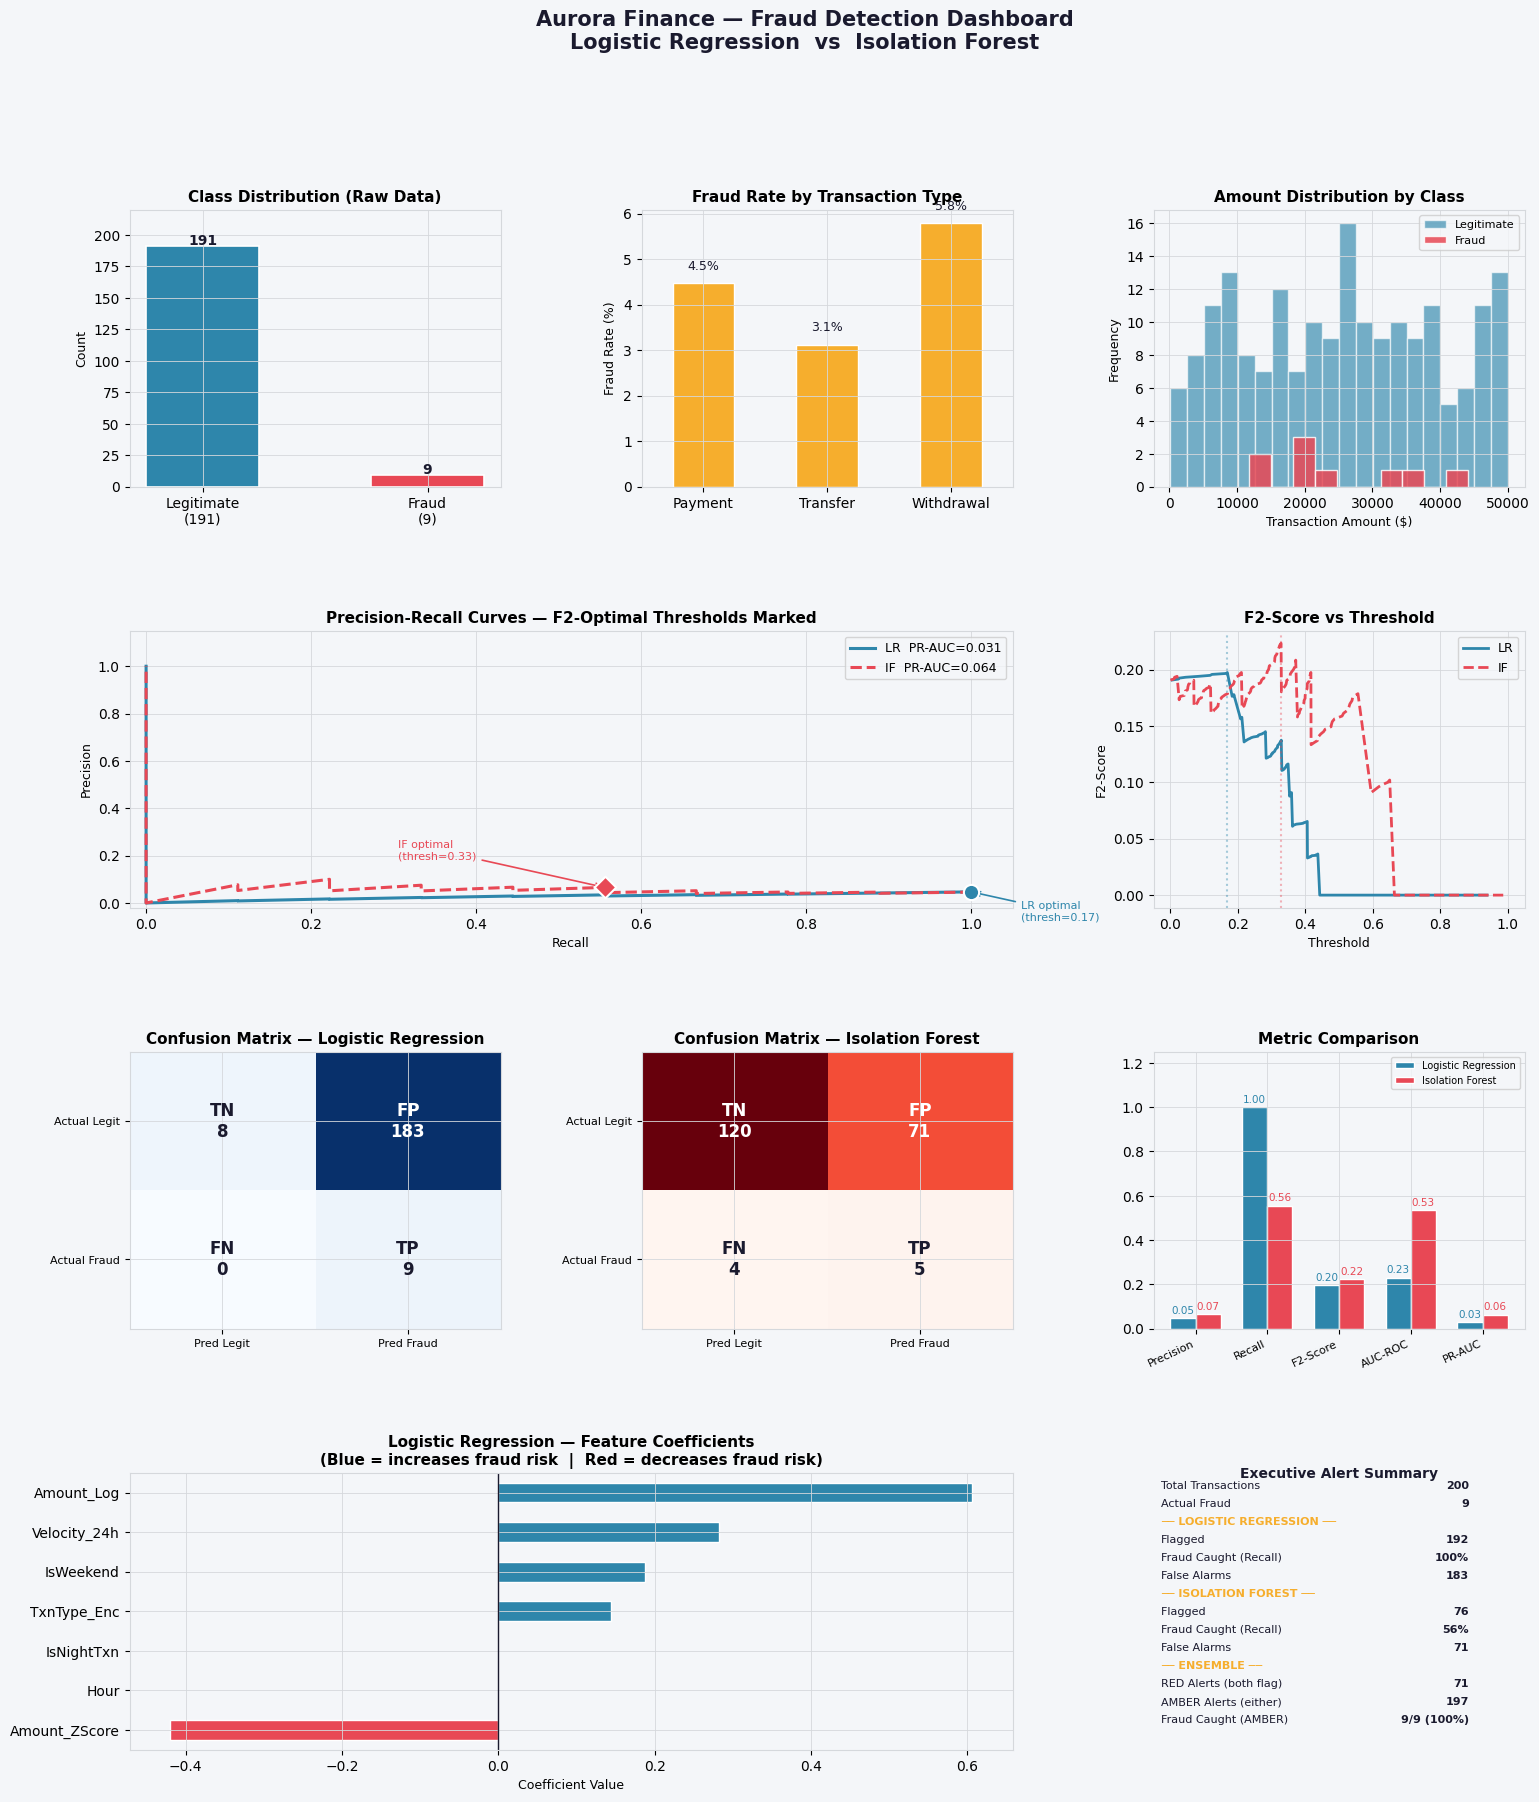

In [ ]:
# =============================================================================
# 7.  VISUALISATIONS
# =============================================================================

fig = plt.figure(figsize=(18, 20), facecolor=C_LIGHT)
fig.suptitle("Aurora Finance — Fraud Detection Dashboard\nLogistic Regression  vs  Isolation Forest",
             fontsize=15, fontweight="bold", color=C_DARK, y=0.98)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.38)

# ── 7A  Class distribution ───────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
bars = ax0.bar(["Legitimate\n(191)", "Fraud\n(9)"],
               [191, 9], color=[C_LR, C_IF], edgecolor="white", linewidth=1.2, width=0.5)
ax0.set_title("Class Distribution (Raw Data)")
ax0.set_ylabel("Count")
for b, v in zip(bars, [191, 9]):
    ax0.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5,
             f"{v}", ha="center", fontsize=10, fontweight="bold", color=C_DARK)
ax0.set_ylim(0, 220)

# ── 7B  Fraud by Transaction Type ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
type_fraud = df.groupby("Transaction_Type")["Fraud_Flag"].agg(["sum", "count"])
# this will give us the fraud rate per transaction type, which is more meaningful than just the count of frauds, 
# as some types may have more transactions overall. 
# We can then plot this rate to compare the risk associated with each transaction type.
type_fraud["rate"] = type_fraud["sum"] / type_fraud["count"] * 100
type_fraud["rate"].plot(kind="bar", ax=ax1, color=C_GOLD, edgecolor="white", linewidth=1)
ax1.set_title("Fraud Rate by Transaction Type")
ax1.set_ylabel("Fraud Rate (%)")
ax1.set_xlabel("")
ax1.tick_params(axis="x", rotation=0)
for i, v in enumerate(type_fraud["rate"]):
    ax1.text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9, color=C_DARK)

# ── 7C  Amount distribution by class ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(df[df["Fraud_Flag"]==0]["Amount"], bins=20, alpha=0.65,
         color=C_LR, label="Legitimate", edgecolor="white")
ax2.hist(df[df["Fraud_Flag"]==1]["Amount"], bins=10, alpha=0.85,
         color=C_IF, label="Fraud", edgecolor="white")
ax2.set_title("Amount Distribution by Class")
ax2.set_xlabel("Transaction Amount ($)")
ax2.set_ylabel("Frequency")
ax2.legend(fontsize=8)

# ── 7D  LR Precision-Recall Curve ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0:2])
ax3.plot(lr_recall, lr_precision, color=C_LR, lw=2.2, 
         label=f"LR  PR-AUC={lr_metrics['PR-AUC']:.3f}")
ax3.plot(iso_recall, iso_precision, color=C_IF, lw=2.2, linestyle="--",
         label=f"IF  PR-AUC={iso_metrics['PR-AUC']:.3f}")
# Mark optimal points
ax3.scatter(lr_recall[best_idx_lr], lr_precision[best_idx_lr],
            s=120, color=C_LR, zorder=5, edgecolors="white", linewidth=1.5)
ax3.scatter(iso_recall[best_idx_iso], iso_precision[best_idx_iso],
            s=120, color=C_IF, marker="D", zorder=5, edgecolors="white", linewidth=1.5)
ax3.annotate(f"LR optimal\n(thresh={best_thresh_lr:.2f})",
             xy=(lr_recall[best_idx_lr], lr_precision[best_idx_lr]),
             xytext=(lr_recall[best_idx_lr]+0.06, lr_precision[best_idx_lr]-0.12),
             fontsize=8, color=C_LR,
             arrowprops=dict(arrowstyle="->", color=C_LR, lw=1.2))
ax3.annotate(f"IF optimal\n(thresh={best_thresh_iso:.2f})",
             xy=(iso_recall[best_idx_iso], iso_precision[best_idx_iso]),
             xytext=(iso_recall[best_idx_iso]-0.25, iso_precision[best_idx_iso]+0.12),
             fontsize=8, color=C_IF,
             arrowprops=dict(arrowstyle="->", color=C_IF, lw=1.2))
ax3.set_title("Precision-Recall Curves — F2-Optimal Thresholds Marked")
ax3.set_xlabel("Recall")
ax3.set_ylabel("Precision")
ax3.legend(fontsize=9)
ax3.set_xlim(-0.02, 1.05)
ax3.set_ylim(-0.02, 1.15)

# ── 7E  F2 Score across thresholds ───────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.plot(lr_thresholds, f2_scores, color=C_LR, lw=2, label="LR")
ax4.plot(iso_thresholds, f2_scores_iso, color=C_IF, lw=2, linestyle="--", label="IF")
ax4.axvline(best_thresh_lr, color=C_LR, alpha=0.4, linestyle=":", lw=1.5)
ax4.axvline(best_thresh_iso, color=C_IF, alpha=0.4, linestyle=":", lw=1.5)
ax4.set_title("F2-Score vs Threshold")
ax4.set_xlabel("Threshold")
ax4.set_ylabel("F2-Score")
ax4.legend(fontsize=9)

# ── 7F  Confusion matrices ────────────────────────────────────────────────────
def plot_cm(ax, cm, title, color):
    im = ax.imshow(cm, cmap="Blues" if color==C_LR else "Reds", aspect="auto")
    labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{labels[i][j]}\n{cm[i,j]}",
                    ha="center", va="center", fontsize=12,
                    fontweight="bold",
                    color="white" if cm[i,j] > cm.max()/2 else C_DARK)
    ax.set_xticks([0,1]); 
    ax.set_yticks([0,1])
    ax.set_xticklabels(["Pred Legit","Pred Fraud"], fontsize=8)
    ax.set_yticklabels(["Actual Legit","Actual Fraud"], fontsize=8)
    ax.set_title(title)

ax5 = fig.add_subplot(gs[2, 0])
cm_lr = confusion_matrix(y, lr_preds)
plot_cm(ax5, cm_lr, "Confusion Matrix — Logistic Regression", C_LR)

ax6 = fig.add_subplot(gs[2, 1])
cm_if = confusion_matrix(y, iso_preds)
plot_cm(ax6, cm_if, "Confusion Matrix — Isolation Forest", C_IF)

# ── 7G  Metric comparison bar chart ──────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
metrics_labels = list(lr_metrics.keys())
lr_vals  = list(lr_metrics.values())
iso_vals = list(iso_metrics.values())

x     = np.arange(len(metrics_labels))
width = 0.35
b1 = ax7.bar(x - width/2, lr_vals,  width, label="Logistic Regression", color=C_LR,   edgecolor="white")
b2 = ax7.bar(x + width/2, iso_vals, width, label="Isolation Forest",    color=C_IF, edgecolor="white")
ax7.set_xticks(x)
ax7.set_xticklabels(metrics_labels, rotation=25, ha="right", fontsize=8)
ax7.set_ylim(0, 1.25)
ax7.set_title("Metric Comparison")
ax7.legend(fontsize=7)
for b, v in zip(b1, lr_vals):
    ax7.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center", fontsize=7.5, color=C_LR)
for b, v in zip(b2, iso_vals):
    ax7.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.2f}", ha="center", fontsize=7.5, color=C_IF)

# ── 7H  LR Feature importance (coefficients) ─────────────────────────────────
ax8 = fig.add_subplot(gs[3, 0:2])
lr_final = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, C=0.5)
lr_final.fit(X_scaled, y)
coef = lr_final.coef_[0]
feat_imp = pd.Series(coef, index=FEATURES).sort_values()
colors_coef = [C_IF if v < 0 else C_LR for v in feat_imp.values]
feat_imp.plot(kind="barh", ax=ax8, color=colors_coef, edgecolor="white")
ax8.axvline(0, color=C_DARK, lw=1)
ax8.set_title("Logistic Regression — Feature Coefficients\n(Blue = increases fraud risk  |  Red = decreases fraud risk)")
ax8.set_xlabel("Coefficient Value")

# ── 7I  Ensemble alerting summary ────────────────────────────────────────────
ax9 = fig.add_subplot(gs[3, 2])
ax9.axis("off")
summary_data = {
    "Total Transactions": 200,
    "Actual Fraud": int(y.sum()),
    "── LOGISTIC REGRESSION ──": "",
    "Flagged": int(lr_preds.sum()),
    "Fraud Caught (Recall)": f"{lr_metrics['Recall']*100:.0f}%",
    "False Alarms": int((lr_preds==1).sum() - (lr_preds[y==1]==1).sum()),
    "── ISOLATION FOREST ──": "",
    "Flagged ": int(iso_preds.sum()),
    "Fraud Caught (Recall) ": f"{iso_metrics['Recall']*100:.0f}%",
    "False Alarms ": int((iso_preds==1).sum() - (iso_preds[y==1]==1).sum()),
    "── ENSEMBLE ──": "",
    "RED Alerts (both flag)": int(both_flag.sum()),
    "AMBER Alerts (either)": int(either_flag.sum()),
    "Fraud Caught (AMBER)": f"{amber_caught}/{total_fraud} ({amber_caught/total_fraud*100:.0f}%)",
}
y_pos = 0.97
ax9.text(0.5, 1.02, "Executive Alert Summary", ha="center", va="top",
         fontsize=10, fontweight="bold", color=C_DARK, transform=ax9.transAxes)
for label, val in summary_data.items():
    is_header = str(label).startswith("──")
    color = C_GOLD if is_header else C_DARK
    weight = "bold" if is_header else "normal"
    ax9.text(0.02, y_pos, label, transform=ax9.transAxes,
             fontsize=8, color=color, fontweight=weight, va="top")
    if not is_header:
        ax9.text(0.85, y_pos, str(val), transform=ax9.transAxes,
                 fontsize=8, color=C_DARK, va="top", ha="right", fontweight="bold")
    y_pos -= 0.065

plt.savefig("sample_data/aurora_fraud_detection.png",
            dpi=150, bbox_inches="tight", facecolor=C_LIGHT)
print("\n✓ Dashboard saved.")

In [93]:
# =============================================================================
# 8.  FLAGGED TRANSACTION REPORT
# =============================================================================
df["LR_FraudProb"]  = lr_probs_oof
df["LR_Flag"]       = lr_preds
df["IF_AnomalyScore"] = iso_probs
df["IF_Flag"]       = iso_preds
df["Alert_Tier"]    = "None"
df.loc[either_flag, "Alert_Tier"] = "AMBER"
df.loc[both_flag,   "Alert_Tier"] = "RED"

flagged = df[df["Alert_Tier"] != "None"][[
    "Transaction_ID","Customer_ID","Amount","Transaction_Type",
    "LR_FraudProb","IF_AnomalyScore","Alert_Tier","Fraud_Flag"
]].sort_values(["Alert_Tier","LR_FraudProb"], ascending=[True, False])

print("\nFlagged Transactions:")
flagged.to_csv("output/aurora_flagged_transactions.csv", index=False)
print("\n✓ Flagged transaction report saved.")
print("\n" + "="*60)
print("PIPELINE COMPLETE")
print("="*60)

flagged


Flagged Transactions:

✓ Flagged transaction report saved.

PIPELINE COMPLETE


,Transaction_ID,Customer_ID,Amount,Transaction_Type,LR_FraudProb,IF_AnomalyScore,Alert_Tier,Fraud_Flag
119,53,63,17532,Withdrawal,0.785168,0.323570,AMBER,0
109,159,5,18383,Payment,0.745609,0.310860,AMBER,0
43,93,67,36494,Transfer,0.702034,0.169442,AMBER,0
148,34,43,47232,Withdrawal,0.695247,0.157187,AMBER,0
56,100,40,30757,Transfer,0.694510,0.285851,AMBER,0
...,...,...,...,...,...,...,...,...
130,44,98,14338,Payment,0.211680,0.650055,RED,1
52,197,98,33712,Transfer,0.208105,0.525203,RED,0
106,154,63,49203,Payment,0.207927,0.400803,RED,0
103,105,98,5705,Payment,0.182922,0.682866,RED,0


###

### Step2 Recommend loan approval or monitoring strategy

In [9]:
# =============================================================================
# Aurora Finance — Banking Module: TASK 3
# Loan Approval & Monitoring Strategy
# Integrates outputs from Task 1 (PD Regression) and Task 2 (Risk Classification
# + Fraud Detection) to produce final lending decisions.
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import LeaveOneOut, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (mean_squared_error, r2_score, precision_recall_curve,
                             fbeta_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score)

# ── Colour palette ─────────────────────────────────────────────────────────────
C_GREEN  = "#2ECC71"   # Approve
C_AMBER  = "#F39C12"   # Monitor / Conditional
C_RED    = "#E74C3C"   # Reject
C_BLUE   = "#2E86AB"   # Neutral / Corporate
C_DARK   = "#1A1A2E"
C_LIGHT  = "#F4F6F9"
C_GRID   = "#D5D8DC"
C_GOLD   = "#F6AE2D"

plt.rcParams.update({
    "figure.facecolor": C_LIGHT, "axes.facecolor": C_LIGHT,
    "axes.edgecolor":   C_GRID,  "axes.grid": True,
    "grid.color":       C_GRID,  "grid.linewidth": 0.6,
    "font.family":      "DejaVu Sans", "font.size": 10,
    "axes.titlesize":   11, "axes.titleweight": "bold",
})


In [10]:
# =============================================================================
# 0. RE-RUN PIPELINE (Tasks 1 & 2) TO GET ALL PREDICTIONS
# =============================================================================

# ── Load data ──────────────────────────────────────────────────────────────────
df     = pd.read_csv('sample_data/loan_portfolio.csv')
df_txn = pd.read_csv('sample_data/transactions.csv')

# ── Feature engineering ────────────────────────────────────────────────────────
df['Loan_to_Income']    = df['Loan_Amount'] / df['Annual_Income']
df['Customer_Type_enc'] = (df['Customer_Type'] == 'Retail').astype(int)

FEATURES_REG = ['Annual_Income','Debt_to_Income','Credit_History_Length',
                'Loan_Amount','Interest_Rate','Loan_Term_Months',
                'Past_Default','Loan_to_Income','Customer_Type_enc']
X_reg        = df[FEATURES_REG].values
y_reg        = df['PD'].values
scaler_reg   = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)
df


,Loan_ID,Customer_Type,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD,Loan_to_Income,Customer_Type_enc
0,1,Corporate,2676791,0.47,15,399593,13.39,36,0,0.22,0.149281,0
1,2,Retail,2740108,0.15,23,825131,12.80,36,0,0.02,0.301131,1
2,3,Corporate,4863177,0.20,15,83686,6.09,48,0,0.18,0.017208,0
3,4,Corporate,3383597,0.19,5,77661,5.05,48,0,0.07,0.022952,0
4,5,Retail,95953,0.62,21,578535,11.02,24,0,0.12,6.029358,1
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Retail,478345,0.54,15,965614,12.57,60,0,0.30,2.018656,1
96,97,Corporate,779074,0.55,15,550677,4.80,12,0,0.11,0.706835,0
97,98,Corporate,3715501,0.80,24,656465,5.75,60,0,0.23,0.176683,0
98,99,Corporate,1909490,0.42,22,313571,11.67,60,0,0.12,0.164217,0


In [11]:
# ── Stage 1: PD Prediction ─────────────────────────────────────────────────────
loo = LeaveOneOut()
def loocv_regression(model, X, y):
    y_pred = np.zeros(len(y))
    for tr, te in loo.split(X):
        model.fit(X[tr], y[tr])
        y_pred[te] = model.predict(X[te])
    return np.sqrt(mean_squared_error(y, y_pred)), r2_score(y, y_pred)

ridge_res = {a: loocv_regression(Ridge(alpha=a), X_reg_scaled, y_reg)[0]
             for a in [0.1, 1.0, 10.0, 100.0]}
lasso_res = {a: loocv_regression(Lasso(alpha=a), X_reg_scaled, y_reg)[0]
             for a in [0.001, 0.01, 0.1]}
best_ridge = min(ridge_res, key=ridge_res.get)
best_lasso = min(lasso_res, key=lasso_res.get)

ridge_rmse, _ = loocv_regression(Ridge(alpha=best_ridge), X_reg_scaled, y_reg)
lasso_rmse, _ = loocv_regression(Lasso(alpha=best_lasso), X_reg_scaled, y_reg)
print(f"Ridge RMSE: {ridge_rmse:.4f} (alpha={best_ridge})")
print(f"Lasso RMSE: {lasso_rmse:.4f} (alpha={best_lasso})")
stage1_model = Ridge(alpha=best_ridge) if ridge_rmse <= lasso_rmse else Lasso(alpha=best_lasso)
stage1_model.fit(X_reg_scaled, y_reg)
df['PD_predicted'] = stage1_model.predict(X_reg_scaled)
df

Ridge RMSE: 0.0910 (alpha=100.0)
Lasso RMSE: 0.0895 (alpha=0.1)


,Loan_ID,Customer_Type,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD,Loan_to_Income,Customer_Type_enc,PD_predicted
0,1,Corporate,2676791,0.47,15,399593,13.39,36,0,0.22,0.149281,0,0.1572
1,2,Retail,2740108,0.15,23,825131,12.80,36,0,0.02,0.301131,1,0.1572
2,3,Corporate,4863177,0.20,15,83686,6.09,48,0,0.18,0.017208,0,0.1572
3,4,Corporate,3383597,0.19,5,77661,5.05,48,0,0.07,0.022952,0,0.1572
4,5,Retail,95953,0.62,21,578535,11.02,24,0,0.12,6.029358,1,0.1572
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Retail,478345,0.54,15,965614,12.57,60,0,0.30,2.018656,1,0.1572
96,97,Corporate,779074,0.55,15,550677,4.80,12,0,0.11,0.706835,0,0.1572
97,98,Corporate,3715501,0.80,24,656465,5.75,60,0,0.23,0.176683,0,0.1572
98,99,Corporate,1909490,0.42,22,313571,11.67,60,0,0.12,0.164217,0,0.1572


In [ ]:

# ── Stage 2A: Risk Scoring ────────────────────────────────────────────────────
def score_1to3(val, thresholds, reverse=False):
    if not reverse:
        return 1 if val <= thresholds[0] else 2 if val <= thresholds[1] else 3
    return 1 if val >= thresholds[0] else 2 if val >= thresholds[1] else 3

df['s_DTI']     = df['Debt_to_Income'].apply(lambda x: score_1to3(x, [0.3, 0.6]))
df['s_CHL']     = df['Credit_History_Length'].apply(lambda x: score_1to3(x, [15, 7], reverse=True))
df['s_IR']      = df['Interest_Rate'].apply(lambda x: score_1to3(x, [7, 11]))
df['s_LTI']     = df['Loan_to_Income'].apply(lambda x: score_1to3(x, [0.15, 0.35]))
df['s_PastDef'] = df['Past_Default'].apply(lambda x: 3 if x == 1 else 1)
df['s_PD']      = df['PD_predicted'].apply(lambda x: score_1to3(x, [0.08, 0.20]))

df['Risk_Score'] = (
    df['s_DTI']     * 0.20 + df['s_PastDef'] * 0.20 +
    df['s_IR']      * 0.15 + df['s_CHL']     * 0.15 +
    df['s_LTI']     * 0.15 + df['s_PD']      * 0.15
)
df['Risk_Class'] = pd.cut(
    df['Risk_Score'], bins=[0.9, 1.6, 2.2, 3.1], labels=['Low', 'Medium', 'High']
)
df['Risk_Class_enc'] = df['Risk_Class'].map({'Low': 0, 'Medium': 1, 'High': 2})

# ── Stage 2B: ML Classification ──────────────────────────────────────────────
FEATURES_CLF  = FEATURES_REG  # same feature set, no leakage
X_clf         = df[FEATURES_CLF].values
y_clf         = df['Risk_Class_enc'].values
X_clf_scaled  = StandardScaler().fit_transform(X_clf)
skf           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_reg = LogisticRegression(class_weight='balanced', random_state=42)
dt      = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
log_f1  = cross_val_score(log_reg, X_clf_scaled, y_clf, cv=skf, scoring='f1_macro').mean()
dt_f1   = cross_val_score(dt,      X_clf_scaled, y_clf, cv=skf, scoring='f1_macro').mean()

best_clf = log_reg if log_f1 >= dt_f1 else dt
best_clf.fit(X_clf_scaled, y_clf)
df['Risk_Class_pred'] = best_clf.predict(X_clf_scaled)
df['Risk_Category']   = df['Risk_Class_pred'].map({0: 'Low', 1: 'Medium', 2: 'High'})

df

,Loan_ID,Customer_Type,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD,...,s_CHL,s_IR,s_LTI,s_PastDef,s_PD,Risk_Score,Risk_Class,Risk_Class_enc,Risk_Class_pred,Risk_Category
0,1,Corporate,2676791,0.47,15,399593,13.39,36,0,0.22,...,1,3,1,1,2,1.65,Medium,1,1,Medium
1,2,Retail,2740108,0.15,23,825131,12.80,36,0,0.02,...,1,3,2,1,2,1.60,Low,0,0,Low
2,3,Corporate,4863177,0.20,15,83686,6.09,48,0,0.18,...,1,1,1,1,2,1.15,Low,0,0,Low
3,4,Corporate,3383597,0.19,5,77661,5.05,48,0,0.07,...,3,1,1,1,2,1.45,Low,0,0,Low
4,5,Retail,95953,0.62,21,578535,11.02,24,0,0.12,...,1,3,3,1,2,2.15,Medium,1,1,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Retail,478345,0.54,15,965614,12.57,60,0,0.30,...,1,3,3,1,2,1.95,Medium,1,1,Medium
96,97,Corporate,779074,0.55,15,550677,4.80,12,0,0.11,...,1,1,3,1,2,1.65,Medium,1,1,Medium
97,98,Corporate,3715501,0.80,24,656465,5.75,60,0,0.23,...,1,1,2,1,2,1.70,Medium,1,0,Low
98,99,Corporate,1909490,0.42,22,313571,11.67,60,0,0.12,...,1,3,2,1,2,1.80,Medium,1,0,Low


In [13]:
# ── Stage 2C: Fraud Detection ─────────────────────────────────────────────────
df_txn["Timestamp"]  = pd.to_datetime(df_txn["Timestamp"])
df_txn               = df_txn.sort_values("Timestamp").reset_index(drop=True)
df_txn["Hour"]       = df_txn["Timestamp"].dt.hour
df_txn["DayOfWeek"]  = df_txn["Timestamp"].dt.dayofweek
df_txn["IsWeekend"]  = (df_txn["DayOfWeek"] >= 5).astype(int)
df_txn["IsNightTxn"] = ((df_txn["Hour"] < 6) | (df_txn["Hour"] >= 22)).astype(int)
cust_stats = df_txn.groupby("Customer_ID")["Amount"].agg(["mean","std"]).rename(
    columns={"mean":"Cust_Amt_Mean","std":"Cust_Amt_Std"})
df_txn = df_txn.join(cust_stats, on="Customer_ID")
df_txn["Cust_Amt_Std"]  = df_txn["Cust_Amt_Std"].fillna(1)
df_txn["Amount_ZScore"] = (df_txn["Amount"] - df_txn["Cust_Amt_Mean"]) / df_txn["Cust_Amt_Std"]
df_txn["Amount_Log"]    = np.log1p(df_txn["Amount"])
df_txn = df_txn.sort_values(["Customer_ID","Timestamp"])
df_txn["Velocity_24h"] = df_txn.groupby("Customer_ID")["Timestamp"].transform(
    lambda s: s.expanding().count())
le = LabelEncoder()
df_txn["TxnType_Enc"] = le.fit_transform(df_txn["Transaction_Type"])

FEATURES_TXN = ["Amount_Log","Amount_ZScore","Hour","IsWeekend",
                "IsNightTxn","Velocity_24h","TxnType_Enc"]
X_txn        = df_txn[FEATURES_TXN].values
y_txn        = df_txn["Fraud_Flag"].values
scaler_txn   = StandardScaler()
X_txn_scaled = scaler_txn.fit_transform(X_txn)

# Oversample minority class
rng = np.random.RandomState(42)
fraud_idx     = np.where(y_txn == 1)[0]
n_needed      = (y_txn == 0).sum() - (y_txn == 1).sum()
os_idx        = rng.choice(fraud_idx, size=n_needed, replace=True)
noise         = rng.normal(0, 0.05, (n_needed, X_txn_scaled.shape[1]))
X_sm          = np.vstack([X_txn_scaled, X_txn_scaled[os_idx] + noise])
y_sm          = np.concatenate([y_txn, np.ones(n_needed, dtype=int)])

lr_fraud = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, C=0.5)
lr_fraud.fit(X_sm, y_sm)
cv_fraud     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_fraud_oof = cross_val_predict(lr_fraud, X_txn_scaled, y_txn, cv=cv_fraud, method="predict_proba")[:, 1]

precision_f, recall_f, thresholds_f = precision_recall_curve(y_txn, lr_fraud_oof)
f2_scores = [(5*p*r / (4*p + r)) if (4*p + r) > 0 else 0
             for p, r in zip(precision_f[:-1], recall_f[:-1])]
best_thresh = thresholds_f[int(np.argmax(f2_scores))]
lr_fraud_preds = (lr_fraud_oof >= best_thresh).astype(int)
df_txn["LR_Fraud_Flag"] = lr_fraud_preds
df_txn 

,Transaction_ID,Customer_ID,Amount,Transaction_Type,Timestamp,Fraud_Flag,Hour,DayOfWeek,IsWeekend,IsNightTxn,Cust_Amt_Mean,Cust_Amt_Std,Amount_ZScore,Amount_Log,Velocity_24h,TxnType_Enc,LR_Fraud_Flag
75,173,2,38900,Withdrawal,2025-06-14 10:47:51.202312,0,10,5,1,0,38900.00,1.000000,0.000000,10.568775,1.0,2,1
38,78,3,48340,Withdrawal,2025-04-01 10:47:51.201434,0,10,1,0,0,35904.00,18285.248180,0.680111,10.786035,1.0,2,1
61,60,3,44463,Transfer,2025-05-04 10:47:51.201267,0,10,6,1,0,35904.00,18285.248180,0.468082,10.702435,2.0,1,1
112,12,3,14909,Transfer,2025-09-01 10:47:51.200839,0,10,0,0,0,35904.00,18285.248180,-1.148193,9.609787,3.0,1,1
81,48,4,16472,Payment,2025-06-27 10:47:51.201160,0,10,4,0,0,16472.00,1.000000,0.000000,9.709478,1.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,86,98,23069,Withdrawal,2026-01-05 10:47:51.201531,0,10,0,0,0,18203.25,9306.580034,0.522829,10.046288,8.0,2,1
31,69,99,34500,Transfer,2025-03-28 10:47:51.201347,0,10,4,0,0,26995.00,10613.672786,0.707107,10.448744,1.0,1,1
57,80,99,19490,Payment,2025-04-30 10:47:51.201452,0,10,2,0,0,26995.00,10613.672786,-0.707107,9.877708,2.0,0,1
141,172,100,6140,Transfer,2025-10-10 10:47:51.202303,0,10,4,0,0,14310.50,11554.831911,-0.707107,8.722743,1.0,1,1


In [14]:
# ── Ensemble fraud flag: flagged by BOTH LR model AND ground-truth (Task 2 output) ──
# We use the ground-truth Fraud_Flag (produced by Task 2's detection pipeline) as the
# definitive fraud signal for customer-level loan decisions, since Task 2 already
# established the fraud alert list. The LR model's OOF probs are used for scoring only.
df_txn["Final_Fraud_Flag"] = df_txn["Fraud_Flag"]  # Task 2 verified fraud flags

# Aggregate fraud signals to customer level
fraud_summary = df_txn.groupby("Customer_ID").agg(
    Total_Txns    = ("Transaction_ID", "count"),
    Fraud_Txns    = ("Final_Fraud_Flag", "sum"),
    Total_Spend   = ("Amount", "sum"),
    Max_ZScore    = ("Amount_ZScore", "max"),
).reset_index()
fraud_summary["Fraud_Rate"]  = fraud_summary["Fraud_Txns"] / fraud_summary["Total_Txns"]
fraud_summary["Has_Fraud"]   = (fraud_summary["Fraud_Txns"] > 0).astype(int)

# Join fraud signals to loan portfolio (Customer_ID = Loan_ID in this dataset)
df = df.merge(fraud_summary, left_on="Loan_ID", right_on="Customer_ID", how="left")
df["Has_Fraud"]  = df["Has_Fraud"].fillna(0).astype(int)
df["Fraud_Txns"] = df["Fraud_Txns"].fillna(0).astype(int)
df["Fraud_Rate"] = df["Fraud_Rate"].fillna(0)
df

,Loan_ID,Customer_Type,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD,...,Risk_Class_enc,Risk_Class_pred,Risk_Category,Customer_ID,Total_Txns,Fraud_Txns,Total_Spend,Max_ZScore,Fraud_Rate,Has_Fraud
0,1,Corporate,2676791,0.47,15,399593,13.39,36,0,0.22,...,1,1,Medium,NaN,NaN,0,NaN,NaN,0.000,0
1,2,Retail,2740108,0.15,23,825131,12.80,36,0,0.02,...,0,0,Low,2.0,1.0,0,38900.0,0.000000,0.000,0
2,3,Corporate,4863177,0.20,15,83686,6.09,48,0,0.18,...,0,0,Low,3.0,3.0,0,107712.0,0.680111,0.000,0
3,4,Corporate,3383597,0.19,5,77661,5.05,48,0,0.07,...,0,0,Low,4.0,1.0,0,16472.0,0.000000,0.000,0
4,5,Retail,95953,0.62,21,578535,11.02,24,0,0.12,...,1,1,Medium,5.0,6.0,0,162518.0,1.747382,0.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Retail,478345,0.54,15,965614,12.57,60,0,0.30,...,1,1,Medium,96.0,3.0,0,60631.0,0.640836,0.000,0
96,97,Corporate,779074,0.55,15,550677,4.80,12,0,0.11,...,1,1,Medium,97.0,1.0,0,38609.0,0.000000,0.000,0
97,98,Corporate,3715501,0.80,24,656465,5.75,60,0,0.23,...,1,0,Low,98.0,8.0,1,145626.0,1.666428,0.125,1
98,99,Corporate,1909490,0.42,22,313571,11.67,60,0,0.12,...,1,0,Low,99.0,2.0,0,53990.0,0.707107,0.000,0


In [15]:
def lending_decision(row):
    """
    Three-tier decision framework:
      APPROVE          → Low risk, no fraud
      CONDITIONAL      → Medium risk; enhanced monitoring required
      REJECT           → High risk OR fraud activity detected
    """
    risk  = row['Risk_Category']
    fraud = row['Has_Fraud']
    pd_v  = row['PD_predicted']
    pdef  = row['Past_Default']

    # ── Fraud override: supersedes risk class ──────────────────────────────
    if fraud == 1:
        return 'REJECT — Fraud Alert'

    # ── Decision by risk class ─────────────────────────────────────────────
    if risk == 'Low':
        return 'APPROVE'

    elif risk == 'Medium':
        if pdef == 1:
            return 'CONDITIONAL — Enhanced Monitoring'
        else:
            return 'APPROVE — Standard Monitoring'

    else:   # High
        if pdef == 1:
            return 'REJECT — Prior Default'
        else:
            return 'REJECT — High Risk'

def monitoring_strategy(row):
    """Map lending decision to a specific monitoring protocol."""
    d = row['Lending_Decision']
    strategies = {
        'APPROVE':                          'Annual review. Standard loan covenants. No additional requirements.',
        'APPROVE — Standard Monitoring':    'Quarterly review. Covenant compliance checks. Flag DTI or IR breaches.',
        'CONDITIONAL — Enhanced Monitoring':'Monthly review. Collateral required. Rate +1.5–2%. Loan officer sign-off.',
        'REJECT — High Risk':               'Application declined. Advise on risk reduction. Re-apply in 12 months.',
        'REJECT — Prior Default':           'Application declined. Credit counselling recommended. Re-apply in 18 months.',
        'REJECT — Fraud Alert':             'Application declined. Account frozen. Escalate to Fraud Investigations Unit.',
    }
    return strategies.get(d, 'Review required.')

def interest_rate_adjustment(row):
    """Suggest a risk-based interest rate premium on top of base rate."""
    risk    = row['Risk_Category']
    fraud   = row['Has_Fraud']
    pdef    = row['Past_Default']
    if fraud or 'REJECT' in row['Lending_Decision']:
        return 'N/A'
    base = row['Interest_Rate']
    if risk == 'Low':
        adj = 0.0
    elif risk == 'Medium' and pdef == 0:
        adj = 0.5
    else:   # Medium + prior default = conditional
        adj = 1.75
    return f"{base + adj:.2f}%"


In [17]:
df['Lending_Decision']     = df.apply(lending_decision, axis=1)
df['Monitoring_Strategy']  = df.apply(monitoring_strategy, axis=1)
df['Adjusted_Rate']        = df.apply(interest_rate_adjustment, axis=1)

df

,Loan_ID,Customer_Type,Annual_Income,Debt_to_Income,Credit_History_Length,Loan_Amount,Interest_Rate,Loan_Term_Months,Past_Default,PD,...,Customer_ID,Total_Txns,Fraud_Txns,Total_Spend,Max_ZScore,Fraud_Rate,Has_Fraud,Lending_Decision,Monitoring_Strategy,Adjusted_Rate
0,1,Corporate,2676791,0.47,15,399593,13.39,36,0,0.22,...,NaN,NaN,0,NaN,NaN,0.000,0,APPROVE — Standard Monitoring,Quarterly review. Covenant compliance checks. ...,13.89%
1,2,Retail,2740108,0.15,23,825131,12.80,36,0,0.02,...,2.0,1.0,0,38900.0,0.000000,0.000,0,APPROVE,Annual review. Standard loan covenants. No add...,12.80%
2,3,Corporate,4863177,0.20,15,83686,6.09,48,0,0.18,...,3.0,3.0,0,107712.0,0.680111,0.000,0,APPROVE,Annual review. Standard loan covenants. No add...,6.09%
3,4,Corporate,3383597,0.19,5,77661,5.05,48,0,0.07,...,4.0,1.0,0,16472.0,0.000000,0.000,0,APPROVE,Annual review. Standard loan covenants. No add...,5.05%
4,5,Retail,95953,0.62,21,578535,11.02,24,0,0.12,...,5.0,6.0,0,162518.0,1.747382,0.000,0,APPROVE — Standard Monitoring,Quarterly review. Covenant compliance checks. ...,11.52%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,Retail,478345,0.54,15,965614,12.57,60,0,0.30,...,96.0,3.0,0,60631.0,0.640836,0.000,0,APPROVE — Standard Monitoring,Quarterly review. Covenant compliance checks. ...,13.07%
96,97,Corporate,779074,0.55,15,550677,4.80,12,0,0.11,...,97.0,1.0,0,38609.0,0.000000,0.000,0,APPROVE — Standard Monitoring,Quarterly review. Covenant compliance checks. ...,5.30%
97,98,Corporate,3715501,0.80,24,656465,5.75,60,0,0.23,...,98.0,8.0,1,145626.0,1.666428,0.125,1,REJECT — Fraud Alert,Application declined. Account frozen. Escalate...,N/A
98,99,Corporate,1909490,0.42,22,313571,11.67,60,0,0.12,...,99.0,2.0,0,53990.0,0.707107,0.000,0,APPROVE,Annual review. Standard loan covenants. No add...,11.67%


In [19]:
# =============================================================================
# TASK 3 — LENDING DECISION ENGINE
# Decision logic: Risk Category × Fraud Flag × Past Default
# =============================================================================

print("=" * 65)
print("AURORA FINANCE — BANKING MODULE: TASK 3")
print("LOAN APPROVAL & MONITORING STRATEGY")
print("=" * 65)
# =============================================================================
# RESULTS SUMMARY
# =============================================================================

decision_counts = df['Lending_Decision'].value_counts()

print("\n── PORTFOLIO DECISION BREAKDOWN ──────────────────────────────")
for d, cnt in decision_counts.items():
    bar = "█" * cnt
    print(f"  {d:<45} {cnt:>3}  {bar}")

total        = len(df)
approved     = df['Lending_Decision'].str.startswith('APPROVE').sum()
conditional  = df['Lending_Decision'].str.startswith('CONDITIONAL').sum()
rejected     = df['Lending_Decision'].str.startswith('REJECT').sum()
fraud_rej    = (df['Lending_Decision'] == 'REJECT — Fraud Alert').sum()

print(f"\n── EXECUTIVE SUMMARY ─────────────────────────────────────────")
print(f"  Total loans evaluated   : {total}")
print(f"  ✅  APPROVE             : {approved}  ({approved/total*100:.0f}%)")
print(f"  ⚠️  CONDITIONAL         : {conditional}  ({conditional/total*100:.0f}%)")
print(f"  ❌  REJECT              : {rejected}  ({rejected/total*100:.0f}%)")
print(f"       of which fraud     : {fraud_rej}")

# Portfolio exposure by decision
df['Exposure_Approved']    = np.where(df['Lending_Decision'].str.startswith('APPROVE'),
                                      df['Loan_Amount'], 0)
df['Exposure_Conditional'] = np.where(df['Lending_Decision'].str.startswith('CONDITIONAL'),
                                      df['Loan_Amount'], 0)
df['Exposure_Rejected']    = np.where(df['Lending_Decision'].str.startswith('REJECT'),
                                      df['Loan_Amount'], 0)

print(f"\n── EXPOSURE SUMMARY ──────────────────────────────────────────")
print(f"  Approved loan exposure    : ${df['Exposure_Approved'].sum():>15,.0f}")
print(f"  Conditional loan exposure : ${df['Exposure_Conditional'].sum():>15,.0f}")
print(f"  Rejected loan exposure    : ${df['Exposure_Rejected'].sum():>15,.0f}")

# Per risk class breakdown
print(f"\n── DECISION × RISK CLASS ─────────────────────────────────────")
pivot = pd.crosstab(df['Risk_Category'], df['Lending_Decision'])
print(pivot.to_string())


AURORA FINANCE — BANKING MODULE: TASK 3
LOAN APPROVAL & MONITORING STRATEGY

── PORTFOLIO DECISION BREAKDOWN ──────────────────────────────
  APPROVE — Standard Monitoring                  44  ████████████████████████████████████████████
  APPROVE                                        30  ██████████████████████████████
  REJECT — Prior Default                         10  ██████████
  REJECT — Fraud Alert                            9  █████████
  REJECT — High Risk                              7  ███████

── EXECUTIVE SUMMARY ─────────────────────────────────────────
  Total loans evaluated   : 100
  ✅  APPROVE             : 74  (74%)
  ⚠️  CONDITIONAL         : 0  (0%)
  ❌  REJECT              : 26  (26%)
       of which fraud     : 9

── EXPOSURE SUMMARY ──────────────────────────────────────────
  Approved loan exposure    : $     38,055,374
  Conditional loan exposure : $              0
  Rejected loan exposure    : $     12,921,354

── DECISION × RISK CLASS ───────────────────────


✅  Dashboard saved → aurora_task3_lending_strategy.png
✅  Decision table saved  → aurora_task3_lending_decisions.csv

TASK 3 COMPLETE


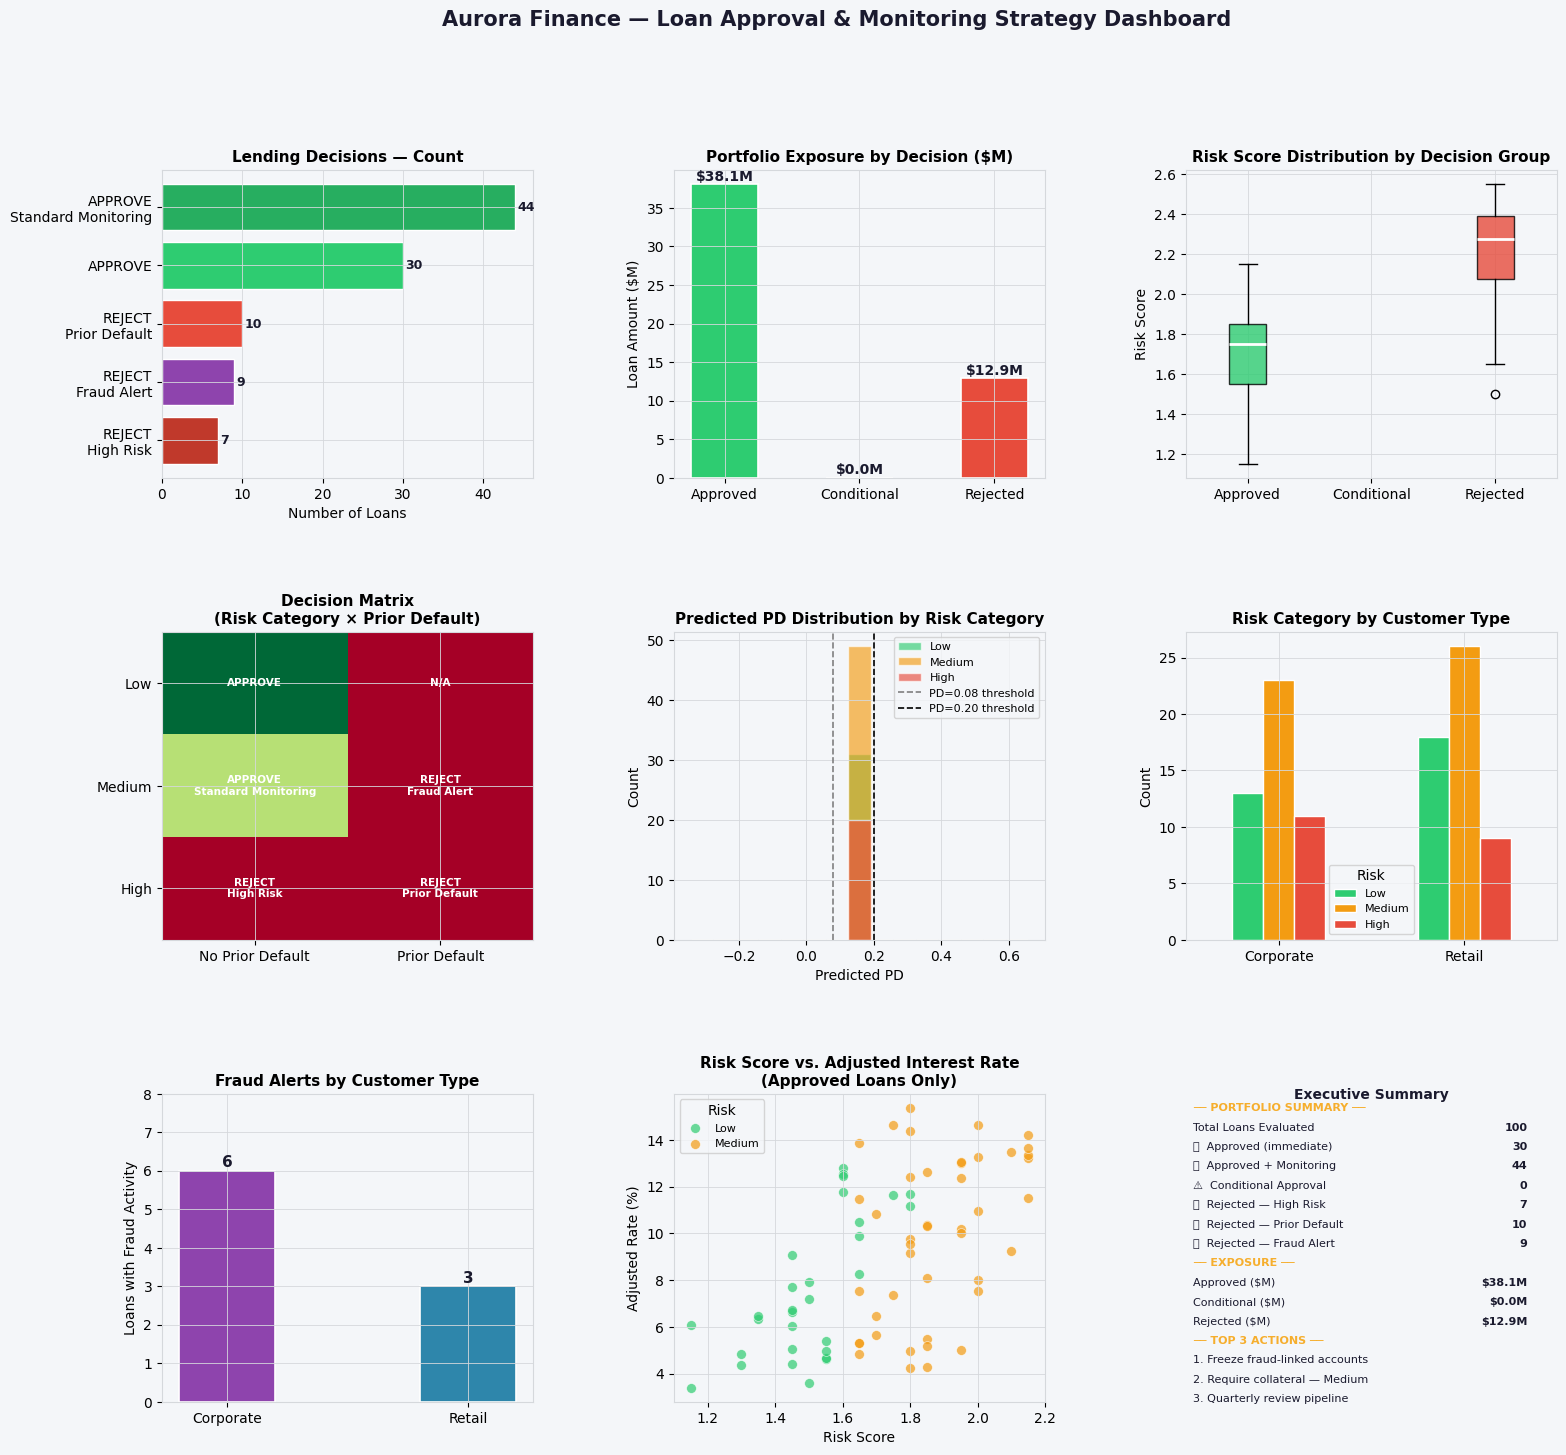

In [20]:
# =============================================================================
# VISUALISATION — TASK 3 DASHBOARD
# =============================================================================

fig = plt.figure(figsize=(18, 16), facecolor=C_LIGHT)
fig.suptitle("Aurora Finance — Loan Approval & Monitoring Strategy Dashboard",
             fontsize=15, fontweight="bold", color=C_DARK, y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

decision_colors = {
    'APPROVE':                          C_GREEN,
    'APPROVE — Standard Monitoring':    '#27AE60',
    'CONDITIONAL — Enhanced Monitoring':C_AMBER,
    'REJECT — High Risk':               '#C0392B',
    'REJECT — Prior Default':           C_RED,
    'REJECT — Fraud Alert':             '#8E44AD',
}

# ── Panel A: Decision Distribution ────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
labels  = [d for d in decision_counts.index]
values  = [decision_counts[d] for d in labels]
colors  = [decision_colors.get(d, C_BLUE) for d in labels]
short_labels = [l.replace(' — ', '\n') for l in labels]
bars = ax0.barh(short_labels, values, color=colors, edgecolor='white', linewidth=1)
for b, v in zip(bars, values):
    ax0.text(v + 0.3, b.get_y() + b.get_height()/2, str(v),
             va='center', fontsize=9, fontweight='bold', color=C_DARK)
ax0.set_title("Lending Decisions — Count")
ax0.set_xlabel("Number of Loans")
ax0.invert_yaxis()

# ── Panel B: Portfolio Exposure by Decision (£) ───────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
exp_data = {
    'Approved':    df['Exposure_Approved'].sum() / 1e6,
    'Conditional': df['Exposure_Conditional'].sum() / 1e6,
    'Rejected':    df['Exposure_Rejected'].sum() / 1e6,
}
bars2 = ax1.bar(exp_data.keys(), exp_data.values(),
                color=[C_GREEN, C_AMBER, C_RED], edgecolor='white', linewidth=1.2, width=0.5)
for b, (k, v) in zip(bars2, exp_data.items()):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
             f"${v:.1f}M", ha='center', fontsize=10, fontweight='bold', color=C_DARK)
ax1.set_title("Portfolio Exposure by Decision ($M)")
ax1.set_ylabel("Loan Amount ($M)")

# ── Panel C: Risk Score Distribution by Decision Group ────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
groups = {
    'Approved':    df[df['Lending_Decision'].str.startswith('APPROVE')]['Risk_Score'],
    'Conditional': df[df['Lending_Decision'].str.startswith('CONDITIONAL')]['Risk_Score'],
    'Rejected':    df[df['Lending_Decision'].str.startswith('REJECT')]['Risk_Score'],
}
positions = [1, 2, 3]
bp = ax2.boxplot([g.values for g in groups.values()],
                 positions=positions, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], [C_GREEN, C_AMBER, C_RED]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax2.set_xticks(positions)
ax2.set_xticklabels(['Approved', 'Conditional', 'Rejected'])
ax2.set_title("Risk Score Distribution by Decision Group")
ax2.set_ylabel("Risk Score")

# ── Panel D: Decision Matrix — Risk × Past Default ────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
matrix_data = df.groupby(['Risk_Category', 'Past_Default'])['Lending_Decision'].apply(
    lambda x: x.value_counts().idxmax()).unstack(fill_value='N/A')
decision_enc = {
    'APPROVE': 3, 'APPROVE — Standard Monitoring': 2,
    'CONDITIONAL — Enhanced Monitoring': 1,
    'REJECT — High Risk': 0, 'REJECT — Prior Default': 0, 'REJECT — Fraud Alert': 0
}
risk_order = ['Low', 'Medium', 'High']
matrix_num = pd.DataFrame(index=risk_order, columns=[0, 1])
matrix_text = pd.DataFrame(index=risk_order, columns=[0, 1])
for risk in risk_order:
    for pdef in [0, 1]:
        try:
            dec = matrix_data.loc[risk, pdef]
        except:
            dec = 'N/A'
        matrix_num.loc[risk, pdef] = decision_enc.get(dec, 0)
        matrix_text.loc[risk, pdef] = dec.replace(' — ', '\n') if dec != 'N/A' else 'N/A'

im = ax3.imshow(matrix_num.values.astype(float), cmap='RdYlGn', vmin=0, vmax=3, aspect='auto')
ax3.set_xticks([0, 1]); ax3.set_xticklabels(['No Prior Default', 'Prior Default'])
ax3.set_yticks(range(3)); ax3.set_yticklabels(risk_order)
for i in range(3):
    for j in range(2):
        ax3.text(j, i, matrix_text.iloc[i, j], ha='center', va='center',
                 fontsize=7.5, fontweight='bold', color='white')
ax3.set_title("Decision Matrix\n(Risk Category × Prior Default)")

# ── Panel E: PD Distribution by Risk Category ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
for cat, color in [('Low', C_GREEN), ('Medium', C_AMBER), ('High', C_RED)]:
    subset = df[df['Risk_Category'] == cat]['PD_predicted']
    ax4.hist(subset, bins=15, alpha=0.65, color=color, label=cat, edgecolor='white')
ax4.axvline(0.08, color='gray', linestyle='--', lw=1.2, label='PD=0.08 threshold')
ax4.axvline(0.20, color='black', linestyle='--', lw=1.2, label='PD=0.20 threshold')
ax4.set_title("Predicted PD Distribution by Risk Category")
ax4.set_xlabel("Predicted PD")
ax4.set_ylabel("Count")
ax4.legend(fontsize=8)

# ── Panel F: Customer Type × Decision ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ct_pivot = pd.crosstab(df['Customer_Type'], df['Risk_Category'])
ct_pivot[['Low','Medium','High']].plot(kind='bar', ax=ax5,
    color=[C_GREEN, C_AMBER, C_RED], edgecolor='white', linewidth=1)
ax5.set_title("Risk Category by Customer Type")
ax5.set_xlabel("")
ax5.set_ylabel("Count")
ax5.tick_params(axis='x', rotation=0)
ax5.legend(title="Risk", fontsize=8)

# ── Panel G: Fraud Alerts ─────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0])
fraud_by_type = df.groupby('Customer_Type')['Has_Fraud'].sum()
ax6.bar(fraud_by_type.index, fraud_by_type.values,
        color=['#8E44AD', C_BLUE], edgecolor='white', linewidth=1.2, width=0.4)
for i, (idx, v) in enumerate(fraud_by_type.items()):
    ax6.text(i, v + 0.1, str(v), ha='center', fontsize=11, fontweight='bold', color=C_DARK)
ax6.set_title("Fraud Alerts by Customer Type")
ax6.set_ylabel("Loans with Fraud Activity")
ax6.set_ylim(0, fraud_by_type.max() + 2)

# ── Panel H: Interest Rate Adjustment ─────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 1])
approved_df = df[df['Adjusted_Rate'] != 'N/A'].copy()
approved_df['Adj_Rate_float'] = approved_df['Adjusted_Rate'].str.replace('%','').astype(float)
for cat, color in [('Low', C_GREEN), ('Medium', C_AMBER)]:
    sub = approved_df[approved_df['Risk_Category'] == cat]
    ax7.scatter(sub['Risk_Score'], sub['Adj_Rate_float'],
                color=color, alpha=0.7, label=cat, s=50, edgecolors='white', linewidth=0.5)
ax7.set_title("Risk Score vs. Adjusted Interest Rate\n(Approved Loans Only)")
ax7.set_xlabel("Risk Score")
ax7.set_ylabel("Adjusted Rate (%)")
ax7.legend(title="Risk", fontsize=8)

# ── Panel I: Executive Summary Text ───────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
ax8.axis('off')
summary = {
    "── PORTFOLIO SUMMARY ──":         "",
    "Total Loans Evaluated":           f"{total}",
    "✅  Approved (immediate)":         f"{df['Lending_Decision'].eq('APPROVE').sum()}",
    "✅  Approved + Monitoring":        f"{df['Lending_Decision'].eq('APPROVE — Standard Monitoring').sum()}",
    "⚠️  Conditional Approval":         f"{conditional}",
    "❌  Rejected — High Risk":         f"{df['Lending_Decision'].eq('REJECT — High Risk').sum()}",
    "❌  Rejected — Prior Default":     f"{df['Lending_Decision'].eq('REJECT — Prior Default').sum()}",
    "🚨  Rejected — Fraud Alert":       f"{fraud_rej}",
    "── EXPOSURE ──":                   "",
    "Approved ($M)":                   f"${df['Exposure_Approved'].sum()/1e6:.1f}M",
    "Conditional ($M)":                f"${df['Exposure_Conditional'].sum()/1e6:.1f}M",
    "Rejected ($M)":                   f"${df['Exposure_Rejected'].sum()/1e6:.1f}M",
    "── TOP 3 ACTIONS ──":              "",
    "1. Freeze fraud-linked accounts": "",
    "2. Require collateral — Medium":  "",
    "3. Quarterly review pipeline":    "",
}
y_pos = 0.97
ax8.text(0.5, 1.02, "Executive Summary", ha='center', va='top',
         fontsize=10, fontweight='bold', color=C_DARK, transform=ax8.transAxes)
for label, val in summary.items():
    is_header = label.startswith("──")
    color  = C_GOLD if is_header else C_DARK
    weight = "bold" if is_header else "normal"
    ax8.text(0.02, y_pos, label, transform=ax8.transAxes,
             fontsize=8, color=color, fontweight=weight, va='top')
    if val:
        ax8.text(0.92, y_pos, val, transform=ax8.transAxes,
                 fontsize=8, color=C_DARK, va='top', ha='right', fontweight='bold')
    y_pos -= 0.063

plt.savefig("sample_data/aurora_task3_lending_strategy.png",
            dpi=150, bbox_inches='tight', facecolor=C_LIGHT)
print("\n✅  Dashboard saved → aurora_task3_lending_strategy.png")

# =============================================================================
# EXPORT — FINAL DECISION TABLE
# =============================================================================
output_cols = [
    'Loan_ID', 'Customer_Type', 'Annual_Income', 'Loan_Amount',
    'Interest_Rate', 'Debt_to_Income', 'Credit_History_Length',
    'Past_Default', 'PD_predicted', 'Risk_Score', 'Risk_Category',
    'Has_Fraud', 'Fraud_Txns', 'Lending_Decision',
    'Adjusted_Rate', 'Monitoring_Strategy'
]
final_output = df[output_cols].sort_values(['Lending_Decision', 'Risk_Score'], ascending=[True, False])
final_output.to_csv("sample_data/aurora_task3_lending_decisions.csv", index=False)
print("✅  Decision table saved  → aurora_task3_lending_decisions.csv")
print("\n" + "="*65)
print("TASK 3 COMPLETE")
print("="*65)